## Data analysis, all plots got merged into one code cell (in three parts), for clarity!

In [ ]:
from jarvis.db.figshare import data as jdata
raw = jdata("hmof")
print("Keys in first entry:")
for k, v in raw[0].items():
    print(f"  {k!r}: {str(v)[:80]}")

Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
Keys in first entry:
  'id': hMOF-3476
  'atoms': {'lattice_mat': [[19.077068000000008, 0.0, 0.0], [0.8508174300693016, 21.3784313
  'max_co2_adsp': 2.87034
  'min_co2_adsp': 0.012105
  'lcd': 20.75
  'pld': 19.25
  'void_fraction': 0.8916609999999999
  'surface_area_m2g': 5173.4
  'surface_area_m2cm3': 1444.8
  'co2_pressures': [0.01, 0.05, 0.1, 0.5, 2.5]
  'co2_absp': [0.012105, 0.0494431, 0.206808, 0.8691749999999999, 2.87034]


Reading prediction CSVs from zip files...
  m2g  -> hmof_surface_area_m2g_alignnn/prediction_results_test_set.csv
  m2cm3 -> hmof_surface_area_m2cm3_alignnn/prediction_results_test_set.csv

  m2g   MAE = 91.15 m2/g   (N=13765)
  m2cm3 MAE = 107.81 m2/cm3  (N=13765)

Loading hMOF dataset from JARVIS...
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
  Loaded 137652 entries.
  131387 entries with complete data.

  m2g   after merge: 13132 structures
  m2cm3 after merge: 13132 structures
  both  after merge: 13132 structures

Generating Figure 1...


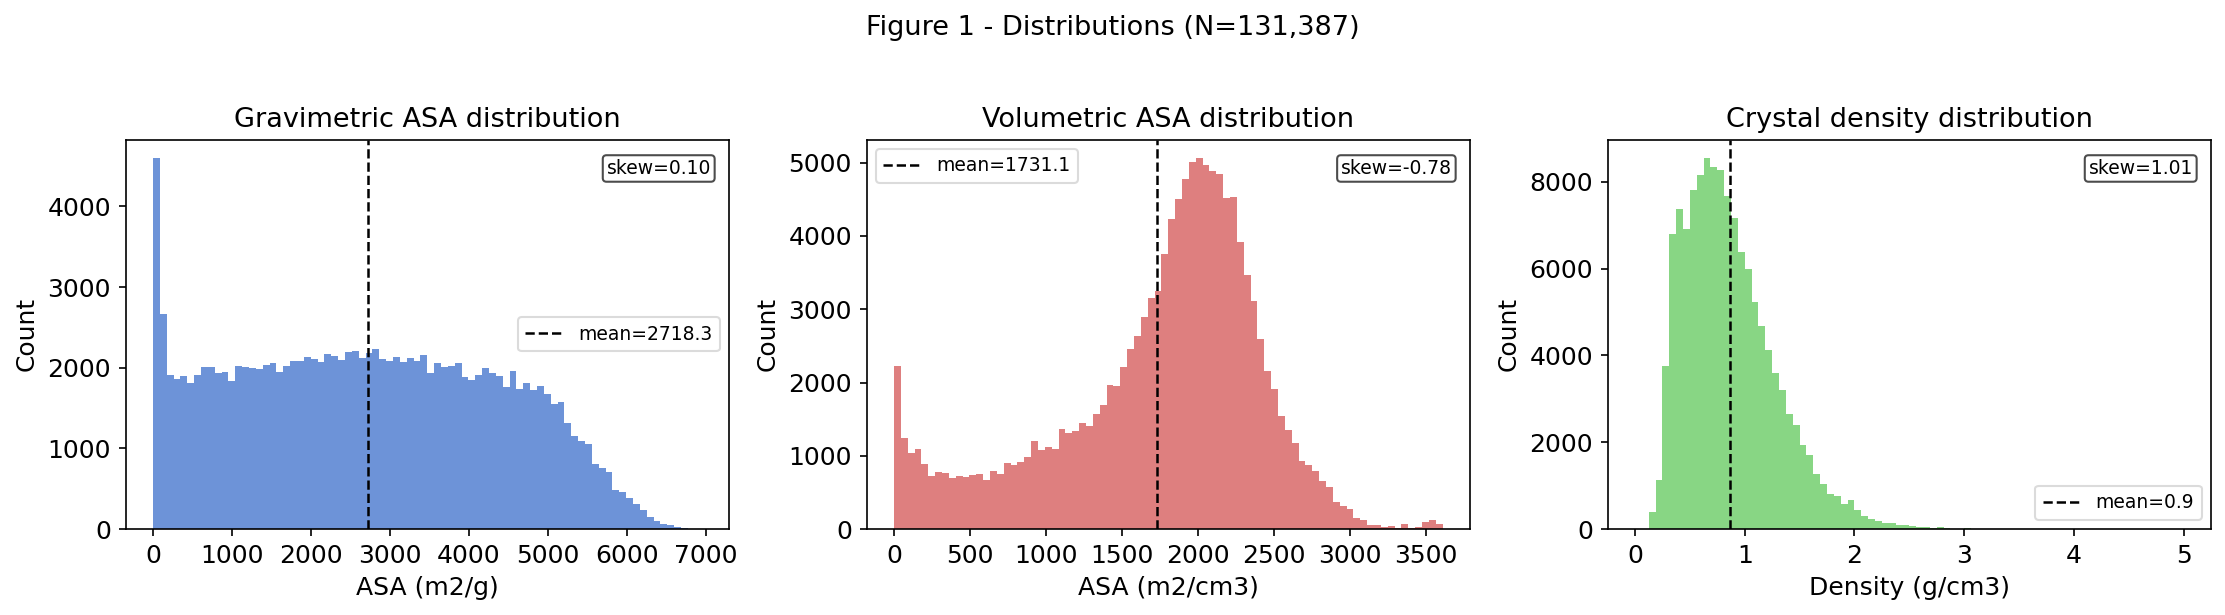

  Saved fig1_distributions.png
Generating Figure 2...


/tmp/ipykernel_117879/3161564947.py:175: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.8)


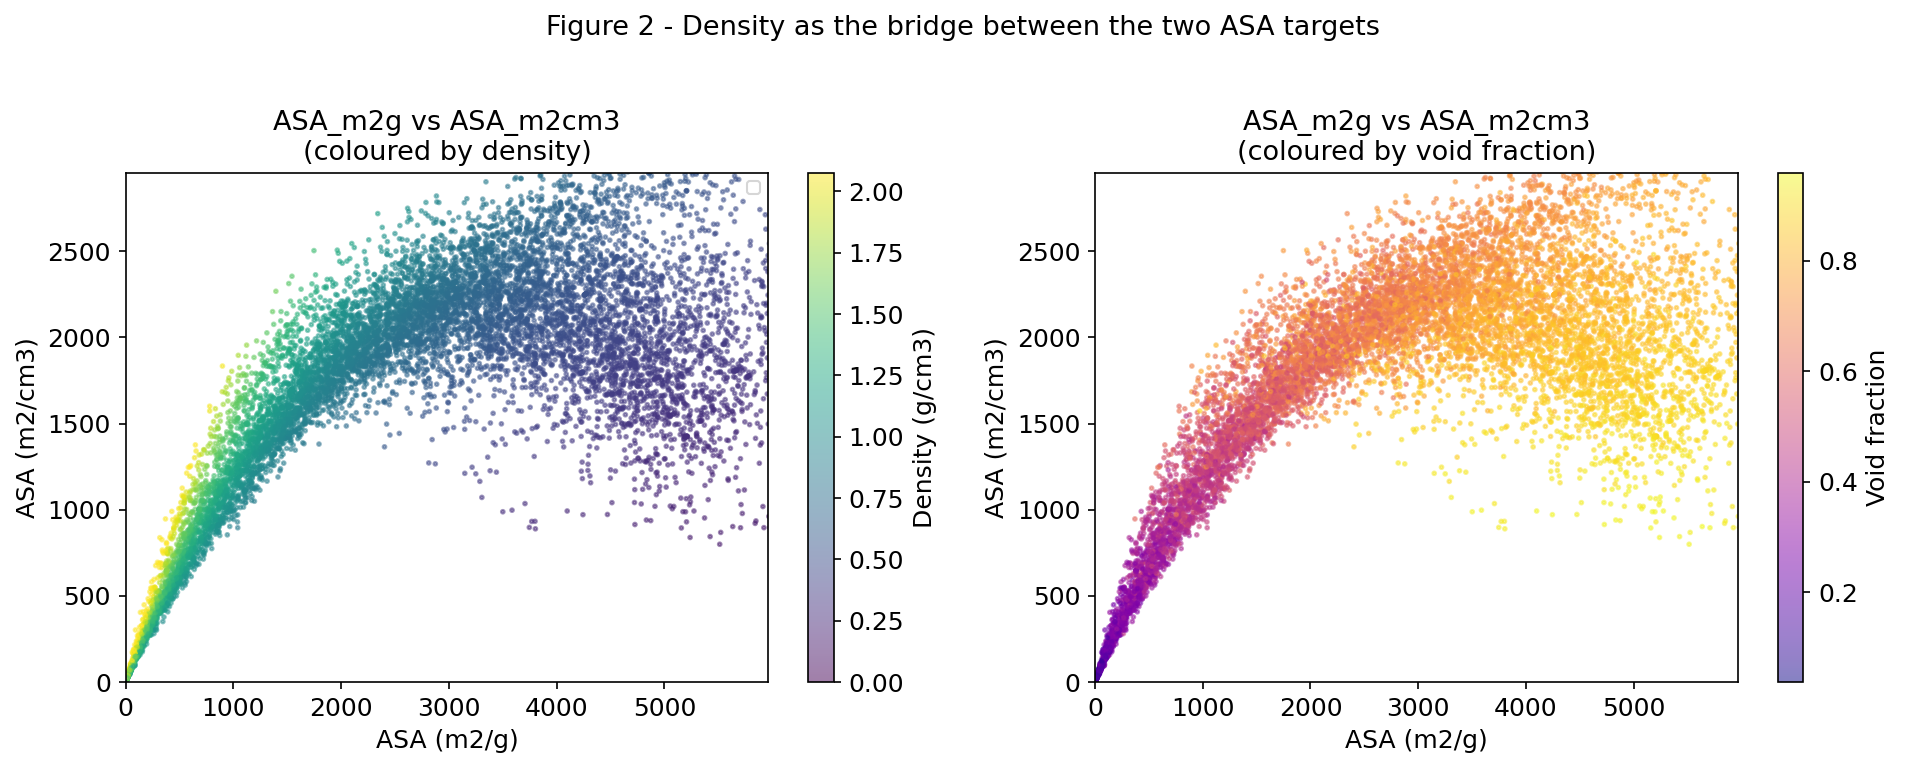

  Saved fig2_density_bridge.png
Generating Figure 3...


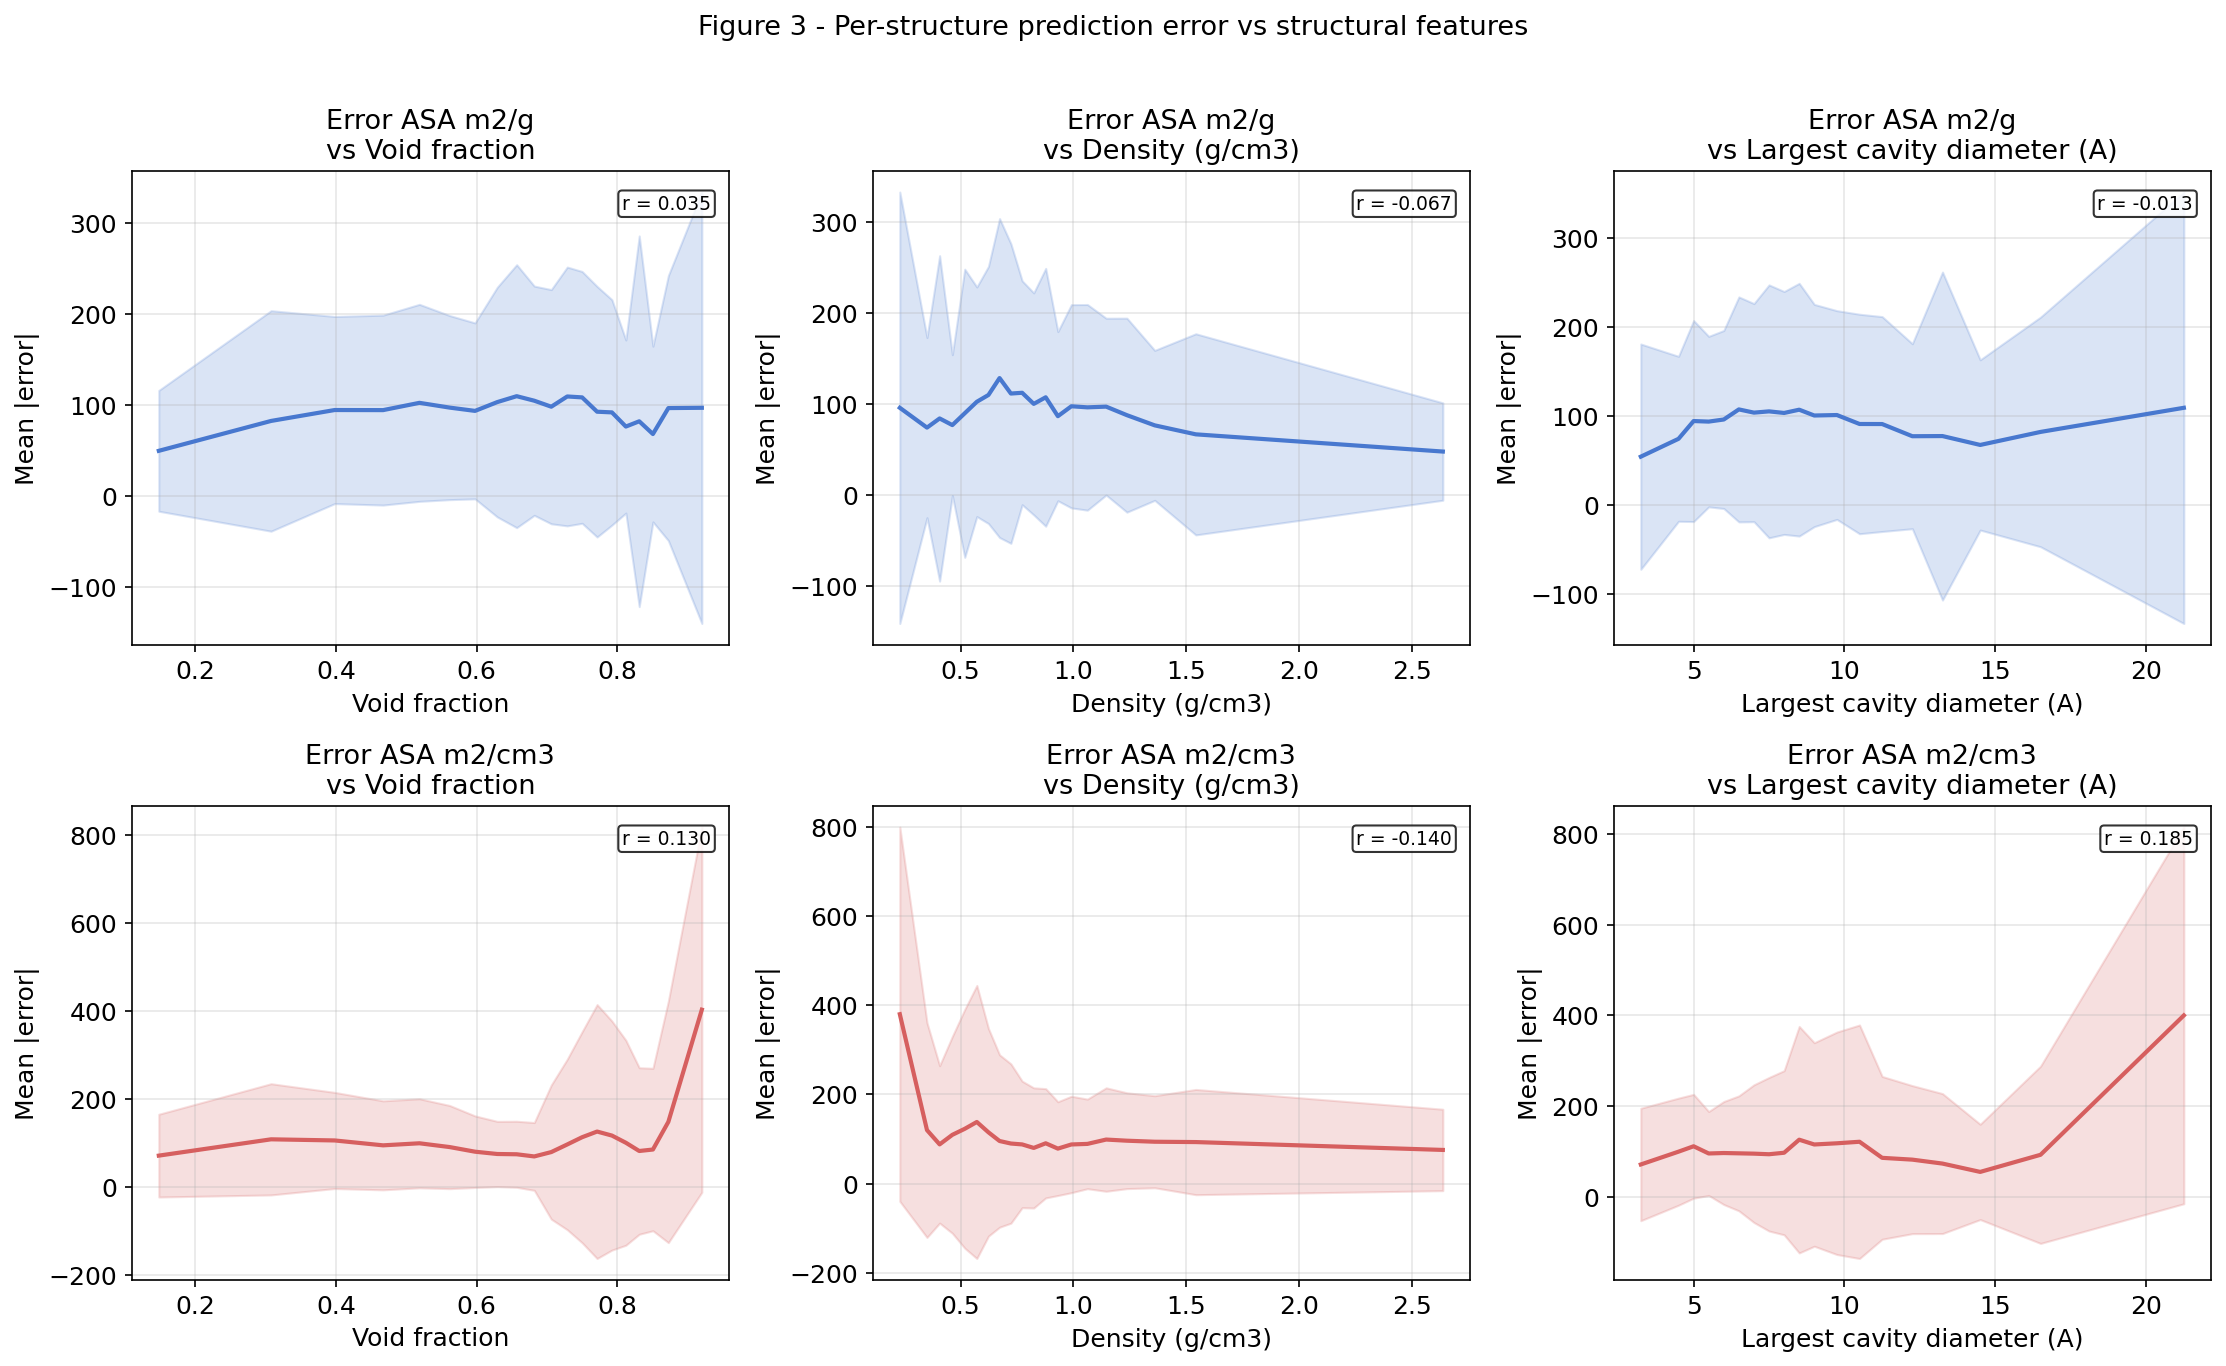

  Saved fig3_error_vs_features.png
Generating Figure 4...


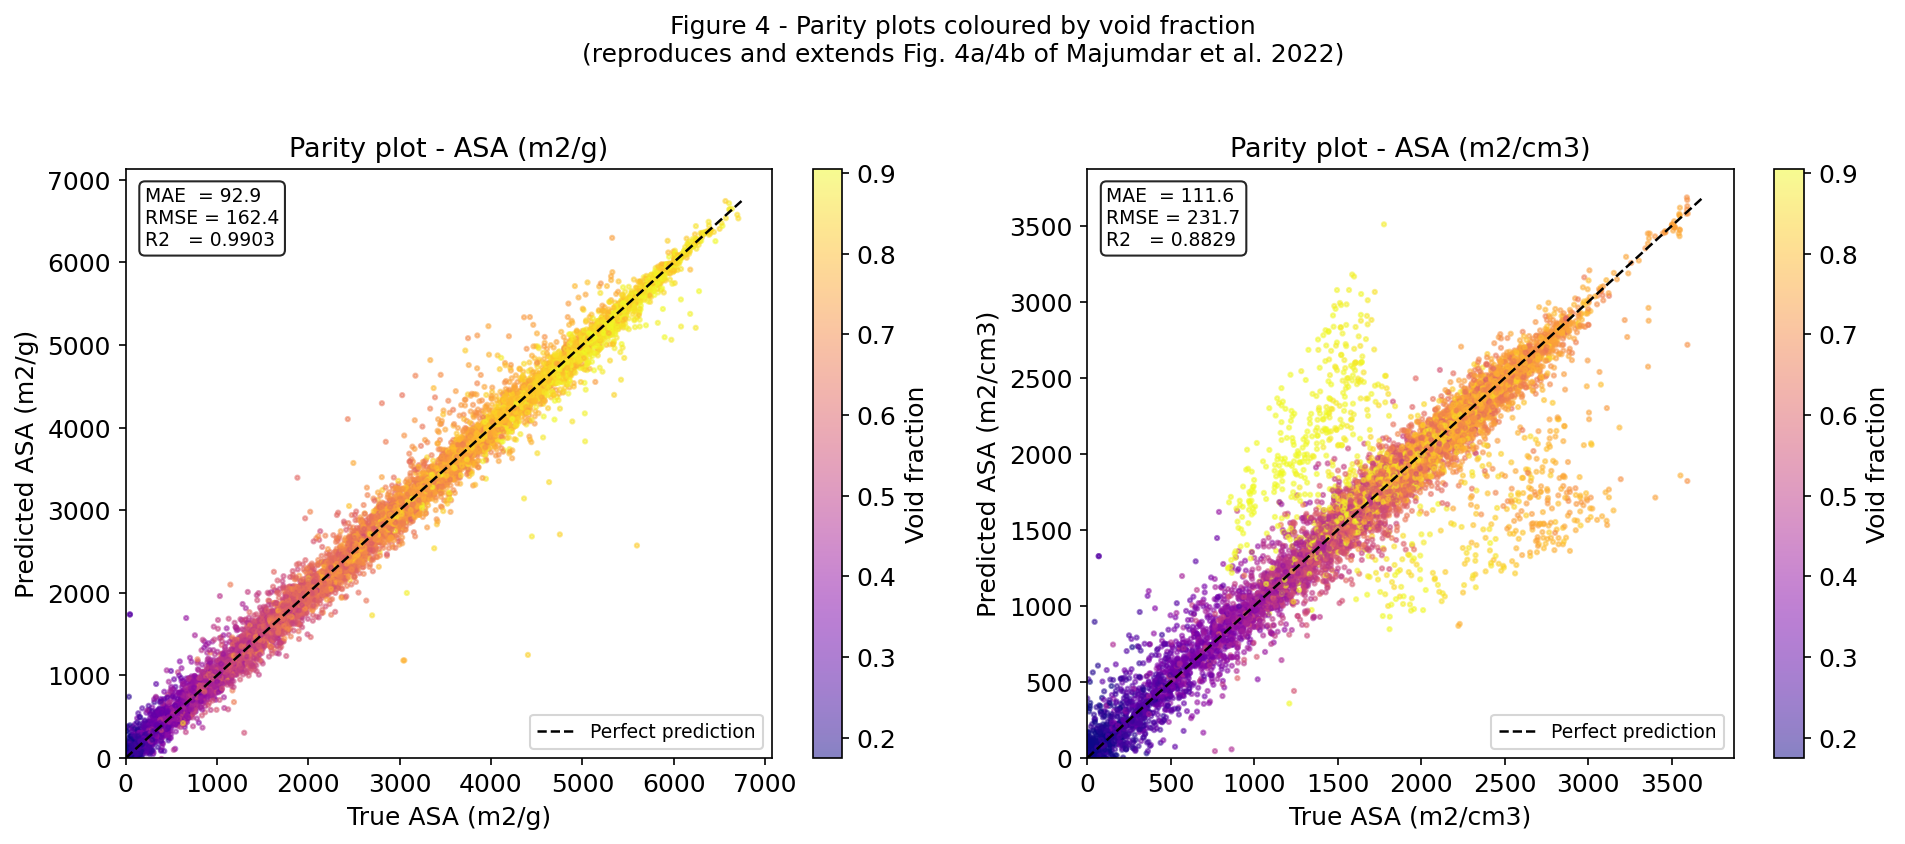

  Saved fig4_parity_plots.png
Generating Figure 5...


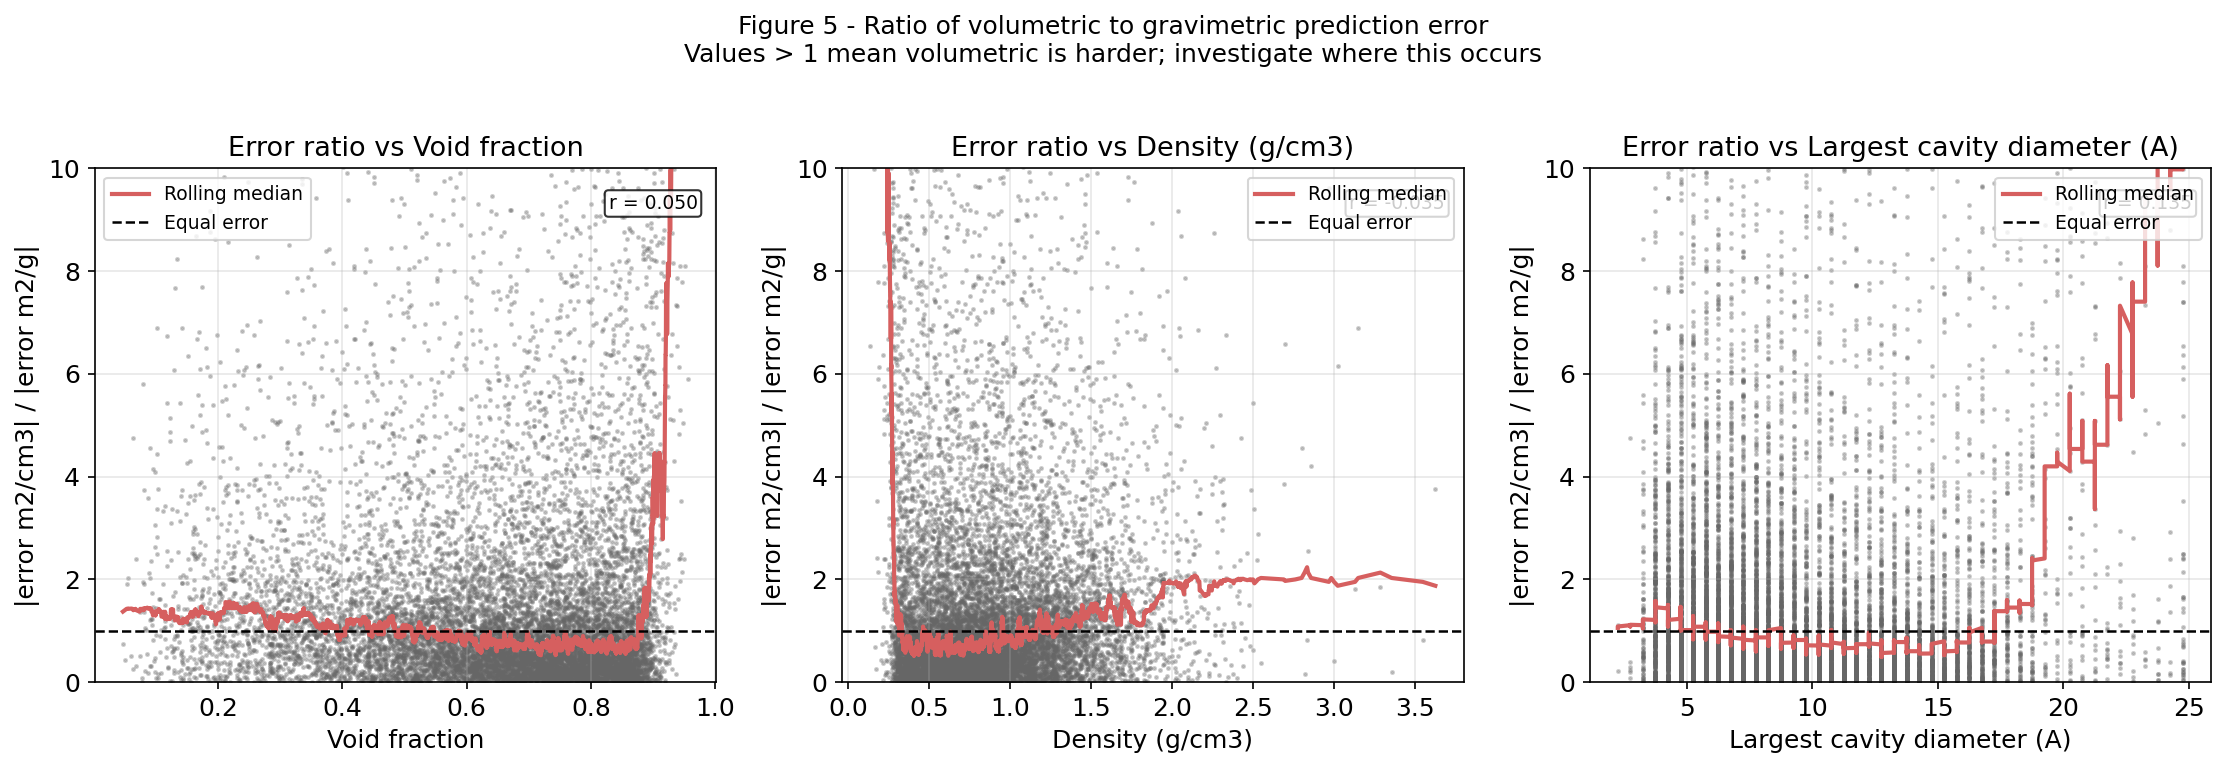

  Saved fig5_error_ratio.png

SUMMARY STATISTICS
                Quantity      N       Mean         Std    Median        Skew
    ASA m2/g  (all hMOF) 131387    2718.32     1653.42   2683.90       0.103
   ASA m2/cm3 (all hMOF) 131387    1731.11      686.42   1891.40      -0.781
Density g/cm3 (all hMOF) 131387       0.87        0.42      0.80       1.015
Void fraction (all hMOF) 131387       0.65        0.19      0.69      -0.855
        Model - ASA m2/g  13132  MAE=92.86 RMSE=162.40 R2=0.9903 MedAE=56.07
      Model - ASA m2/cm3  13132 MAE=111.60 RMSE=231.73 R2=0.8829 MedAE=50.00

All done - figures saved to ./asa_analysis_output/


In [ ]:
# COMPLETE ASA ANALYSIS — reads prediction CSVs directly from
# the pretrained model zip files (no re-inference needed).
#
# Requires:
#   ~/Downloads/alignn/alignn/hmof_surface_area_m2g_alignn.zip
#   ~/Downloads/alignn/alignn/hmof_surface_area_m2cm3_alignn.zip
#
# Output: figures saved to ./asa_analysis_output/

import os, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

OUTPUT_DIR = "./asa_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
})

ZIP_M2G   = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2g_alignn.zip")
ZIP_M2CM3 = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2cm3_alignn.zip")

# Read prediction CSVs directly from the zip files
# Each zip already contains prediction_results_test_set.csv written by the
# original authors when they trained the model, these are the correct
# test-set predictions on the proper train/test split.

print("Reading prediction CSVs from zip files...")

with zipfile.ZipFile(ZIP_M2G) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    print(f"  m2g  -> {csv_name}")
    df_m2g = pd.read_csv(
        io.BytesIO(zp.read(csv_name)),
        names=["id", "true_m2g", "pred_m2g"],
        skiprows=1,
    )

with zipfile.ZipFile(ZIP_M2CM3) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    print(f"  m2cm3 -> {csv_name}")
    df_m2cm3 = pd.read_csv(
        io.BytesIO(zp.read(csv_name)),
        names=["id", "true_m2cm3", "pred_m2cm3"],
        skiprows=1,
    )

# Clean IDs
for df in [df_m2g, df_m2cm3]:
    df["id"] = df["id"].astype(str).str.strip()

mae_m2g   = (df_m2g["true_m2g"]     - df_m2g["pred_m2g"]    ).abs().mean()
mae_m2cm3 = (df_m2cm3["true_m2cm3"] - df_m2cm3["pred_m2cm3"]).abs().mean()
print(f"\n  m2g   MAE = {mae_m2g:.2f} m2/g   (N={len(df_m2g)})")
print(f"  m2cm3 MAE = {mae_m2cm3:.2f} m2/cm3  (N={len(df_m2cm3)})")

# Load hMOF structural features from JARVIS

print("\nLoading hMOF dataset from JARVIS...")
from jarvis.db.figshare import data as jdata
raw = jdata("hmof")
print(f"  Loaded {len(raw)} entries.")

records = []
for row in raw:
    try:
        records.append({
            "id":                 str(row["id"]),
            "surface_area_m2g":   float(row.get("surface_area_m2g",   float("nan"))),
            "surface_area_m2cm3": float(row.get("surface_area_m2cm3", float("nan"))),
            "void_fraction":      float(row.get("void_fraction",       float("nan"))),
            "lcd":                float(row.get("lcd",                 float("nan"))),
            "pld":                float(row.get("pld",                 float("nan"))),
        })
    except Exception:
        continue

hmof_df = pd.DataFrame(records).dropna()
# Derive density = ASA_m2cm3 / ASA_m2g  (not stored directly in hMOF)
valid = hmof_df["surface_area_m2g"] > 0
hmof_df.loc[valid, "density"] = (
    hmof_df.loc[valid, "surface_area_m2cm3"] / hmof_df.loc[valid, "surface_area_m2g"]
)
hmof_df = hmof_df.dropna(subset=["density"])
print(f"  {len(hmof_df)} entries with complete data.")

# Merge predictions with structural features
# The two models may have different test sets so we merge each separately.
# For figures needing both targets we inner-join on the overlapping IDs.

pred_m2g   = df_m2g.merge(hmof_df, on="id", how="inner")
pred_m2cm3 = df_m2cm3.merge(hmof_df, on="id", how="inner")
merged_df  = df_m2g.merge(df_m2cm3, on="id").merge(hmof_df, on="id", how="inner")

print(f"\n  m2g   after merge: {len(pred_m2g)} structures")
print(f"  m2cm3 after merge: {len(pred_m2cm3)} structures")
print(f"  both  after merge: {len(merged_df)} structures")

# HELPER

def _add_stats(ax, series):
    ax.axvline(series.mean(), color="black", linestyle="--",
               linewidth=1.2, label=f"mean={series.mean():.1f}")
    ax.legend(fontsize=9, framealpha=0.7)
    ax.text(0.97, 0.95, f"skew={stats.skew(series.dropna()):.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

features = [("void_fraction", "Void fraction"),
            ("density",       "Density (g/cm3)"),
            ("lcd",           "Largest cavity diameter (A)")]

# Distributions

print("\nGenerating Figure 1...")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(hmof_df["surface_area_m2g"], bins=80, color="#4878CF", alpha=0.8, edgecolor="none")
ax.set_xlabel("ASA (m2/g)"); ax.set_ylabel("Count")
ax.set_title("Gravimetric ASA distribution"); _add_stats(ax, hmof_df["surface_area_m2g"])

ax = axes[1]
ax.hist(hmof_df["surface_area_m2cm3"], bins=80, color="#D65F5F", alpha=0.8, edgecolor="none")
ax.set_xlabel("ASA (m2/cm3)"); ax.set_ylabel("Count")
ax.set_title("Volumetric ASA distribution"); _add_stats(ax, hmof_df["surface_area_m2cm3"])

ax = axes[2]
ax.hist(hmof_df["density"], bins=80, color="#6ACC65", alpha=0.8, edgecolor="none")
ax.set_xlabel("Density (g/cm3)"); ax.set_ylabel("Count")
ax.set_title("Crystal density distribution"); _add_stats(ax, hmof_df["density"])

fig.suptitle(f"Figure 1 - Distributions (N={len(hmof_df):,})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_distributions.png")); plt.show()
print("  Saved fig1_distributions.png")

# Density bridge

print("Generating Figure 2...")
df_sample = hmof_df.sample(min(10000, len(hmof_df)), random_state=42)

# FIX: set consistent axis limits for both panels.
# The left panel was stretching to y=10000 because a handful of very
# high-density outliers push rho * x_line way up.  We clip both axes
# to the 99th percentile of the actual data so the bulk of the scatter
# is clearly visible and both panels share the same scale.
x_max = df_sample["surface_area_m2g"].quantile(0.99)
y_max = df_sample["surface_area_m2cm3"].quantile(0.99)

# Also clip the density colour scale to the 99th percentile so a few
# extreme-density outliers don't compress the colour range for everyone.
d_max = df_sample["density"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(df_sample["surface_area_m2g"], df_sample["surface_area_m2cm3"],
                c=df_sample["density"].clip(upper=d_max),
                cmap="viridis", s=3, alpha=0.5, rasterized=True,
                vmin=0, vmax=d_max)
plt.colorbar(sc, ax=ax, label="Density (g/cm3)")
ax.set_xlabel("ASA (m2/g)"); ax.set_ylabel("ASA (m2/cm3)")
ax.set_title("ASA_m2g vs ASA_m2cm3\n(coloured by density)")
ax.set_xlim(0, x_max); ax.set_ylim(0, y_max)
# Reference lines drawn only within the visible axis range
x_line = np.linspace(0, x_max, 100)
ax.legend(fontsize=8, framealpha=0.8)

ax = axes[1]
sc = ax.scatter(df_sample["surface_area_m2g"], df_sample["surface_area_m2cm3"],
                c=df_sample["void_fraction"], cmap="plasma", s=3, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label="Void fraction")
ax.set_xlabel("ASA (m2/g)"); ax.set_ylabel("ASA (m2/cm3)")
ax.set_title("ASA_m2g vs ASA_m2cm3\n(coloured by void fraction)")
ax.set_xlim(0, x_max); ax.set_ylim(0, y_max)

fig.suptitle("Figure 2 - Density as the bridge between the two ASA targets", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_density_bridge.png")); plt.show()
print("  Saved fig2_density_bridge.png")

# Error vs structural features

print("Generating Figure 3...")

def _error_panel(ax, df, err_col, feat_col, feat_label, colour):
    bins = np.unique(np.percentile(df[feat_col].dropna(), np.linspace(0, 100, 21)))
    bin_idx = np.clip(np.digitize(df[feat_col], bins) - 1, 0, len(bins) - 2)
    bm, bs, bc = [], [], []
    for b in range(len(bins) - 1):
        mask = bin_idx == b
        if mask.sum() < 5: continue
        vals = df.loc[mask, err_col].dropna()
        bm.append(vals.mean()); bs.append(vals.std())
        bc.append((bins[b] + bins[b+1]) / 2)
    bm, bs, bc = np.array(bm), np.array(bs), np.array(bc)
    ax.plot(bc, bm, color=colour, linewidth=2)
    ax.fill_between(bc, bm - bs, bm + bs, alpha=0.2, color=colour)
    r, _ = stats.pearsonr(df[feat_col].fillna(df[feat_col].median()),
                           df[err_col].fillna(0))
    ax.text(0.97, 0.95, f"r = {r:.3f}", transform=ax.transAxes, ha="right", va="top",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
    ax.set_xlabel(feat_label); ax.set_ylabel("Mean |error|"); ax.grid(True, alpha=0.3)

pred_m2g["err"]   = np.abs(pred_m2g["pred_m2g"]     - pred_m2g["true_m2g"])
pred_m2cm3["err"] = np.abs(pred_m2cm3["pred_m2cm3"] - pred_m2cm3["true_m2cm3"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col_idx, (feat_col, feat_label) in enumerate(features):
    ax = axes[0][col_idx]
    _error_panel(ax, pred_m2g, "err", feat_col, feat_label, "#4878CF")
    ax.set_title(f"Error ASA m2/g\nvs {feat_label}")
    ax = axes[1][col_idx]
    _error_panel(ax, pred_m2cm3, "err", feat_col, feat_label, "#D65F5F")
    ax.set_title(f"Error ASA m2/cm3\nvs {feat_label}")

fig.suptitle("Figure 3 - Per-structure prediction error vs structural features",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_error_vs_features.png")); plt.show()
print("  Saved fig3_error_vs_features.png")

# Parity plots
print("Generating Figure 4...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
norm = mcolors.Normalize(vmin=merged_df["void_fraction"].quantile(0.02),
                         vmax=merged_df["void_fraction"].quantile(0.98))
for ax, true_col, pred_col, label in [
    (axes[0], "true_m2g",   "pred_m2g",   "ASA (m2/g)"),
    (axes[1], "true_m2cm3", "pred_m2cm3", "ASA (m2/cm3)"),
]:
    sc = ax.scatter(merged_df[true_col], merged_df[pred_col],
                    c=merged_df["void_fraction"], cmap=plt.cm.plasma,
                    norm=norm, s=4, alpha=0.5, rasterized=True)
    lo = max(0, min(merged_df[true_col].min(), merged_df[pred_col].min()))
    hi = max(merged_df[true_col].max(), merged_df[pred_col].max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="Perfect prediction")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    mae  = np.abs(merged_df[true_col] - merged_df[pred_col]).mean()
    rmse = np.sqrt(((merged_df[true_col] - merged_df[pred_col])**2).mean())
    r2   = 1 - ((merged_df[true_col] - merged_df[pred_col])**2).sum() / \
                   ((merged_df[true_col] - merged_df[true_col].mean())**2).sum()
    ax.text(0.03, 0.97, f"MAE  = {mae:.1f}\nRMSE = {rmse:.1f}\nR2   = {r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel(f"True {label}"); ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"Parity plot - {label}"); ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label="Void fraction")
fig.suptitle("Figure 4 - Parity plots coloured by void fraction\n"
             "(reproduces and extends Fig. 4a/4b of Majumdar et al. 2022)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_parity_plots.png")); plt.show()
print("  Saved fig4_parity_plots.png")

# Error ratio

print("Generating Figure 5...")

merged_df["err_m2g"]   = np.abs(merged_df["pred_m2g"]   - merged_df["true_m2g"])
merged_df["err_m2cm3"] = np.abs(merged_df["pred_m2cm3"] - merged_df["true_m2cm3"])
df_ratio = merged_df[merged_df["err_m2g"] > 1.0].copy()
df_ratio["err_ratio"] = df_ratio["err_m2cm3"] / df_ratio["err_m2g"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (feat_col, feat_label) in zip(axes, features):
    ax.scatter(df_ratio[feat_col], df_ratio["err_ratio"],
               s=2, alpha=0.3, color="#666666", rasterized=True)
    order = df_ratio[feat_col].argsort()
    x_s = df_ratio[feat_col].iloc[order].values
    y_s = df_ratio["err_ratio"].iloc[order].values
    window = max(1, len(x_s) // 100)
    y_smooth = pd.Series(y_s).rolling(window, center=True, min_periods=1).median().values
    ax.plot(x_s, y_smooth, color="#D65F5F", linewidth=2, label="Rolling median")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Equal error")
    ax.set_xlabel(feat_label); ax.set_ylabel("|error m2/cm3| / |error m2/g|")
    ax.set_title(f"Error ratio vs {feat_label}")
    ax.set_ylim(0, min(10, df_ratio["err_ratio"].quantile(0.99)))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    r, _ = stats.pearsonr(df_ratio[feat_col].fillna(df_ratio[feat_col].median()),
                           np.clip(df_ratio["err_ratio"], 0, 10))
    ax.text(0.97, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

fig.suptitle("Figure 5 - Ratio of volumetric to gravimetric prediction error\n"
             "Values > 1 mean volumetric is harder; investigate where this occurs",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig5_error_ratio.png")); plt.show()
print("  Saved fig5_error_ratio.png")

# SUMMARY

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

rows = []
for col, label in [("surface_area_m2g",   "ASA m2/g  (all hMOF)"),
                   ("surface_area_m2cm3",  "ASA m2/cm3 (all hMOF)"),
                   ("density",             "Density g/cm3 (all hMOF)"),
                   ("void_fraction",       "Void fraction (all hMOF)")]:
    s = hmof_df[col].dropna()
    rows.append({"Quantity": label, "N": len(s),
                 "Mean": f"{s.mean():.2f}", "Std": f"{s.std():.2f}",
                 "Median": f"{s.median():.2f}", "Skew": f"{stats.skew(s):.3f}"})

for df_p, true_col, pred_col, label in [
    (pred_m2g,   "true_m2g",   "pred_m2g",   "Model - ASA m2/g"),
    (pred_m2cm3, "true_m2cm3", "pred_m2cm3", "Model - ASA m2/cm3"),
]:
    err = np.abs(df_p[true_col] - df_p[pred_col])
    r2  = 1 - ((df_p[true_col] - df_p[pred_col])**2).sum() / \
              ((df_p[true_col] - df_p[true_col].mean())**2).sum()
    rows.append({"Quantity": label, "N": len(err),
                 "Mean": f"MAE={err.mean():.2f}",
                 "Std":  f"RMSE={np.sqrt((err**2).mean()):.2f}",
                 "Median": f"R2={r2:.4f}",
                 "Skew": f"MedAE={err.median():.2f}"})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary.to_csv(os.path.join(OUTPUT_DIR, "summary_stats.csv"), index=False)
print(f"\nAll done - figures saved to {OUTPUT_DIR}/")

Reading prediction CSVs from zip files...
  13765 structures with both predictions

Loading hMOF dataset...
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
  13132 structures after merge

  LCD stats in test set:
    min=2.2 A,  median=8.2 A,  max=24.8 A
    Structures with LCD > 16 A (pore wider than cutoff diameter): 1,094 (8.3%)

Generating Check 1 — LCD vs error (corrected reference line)...


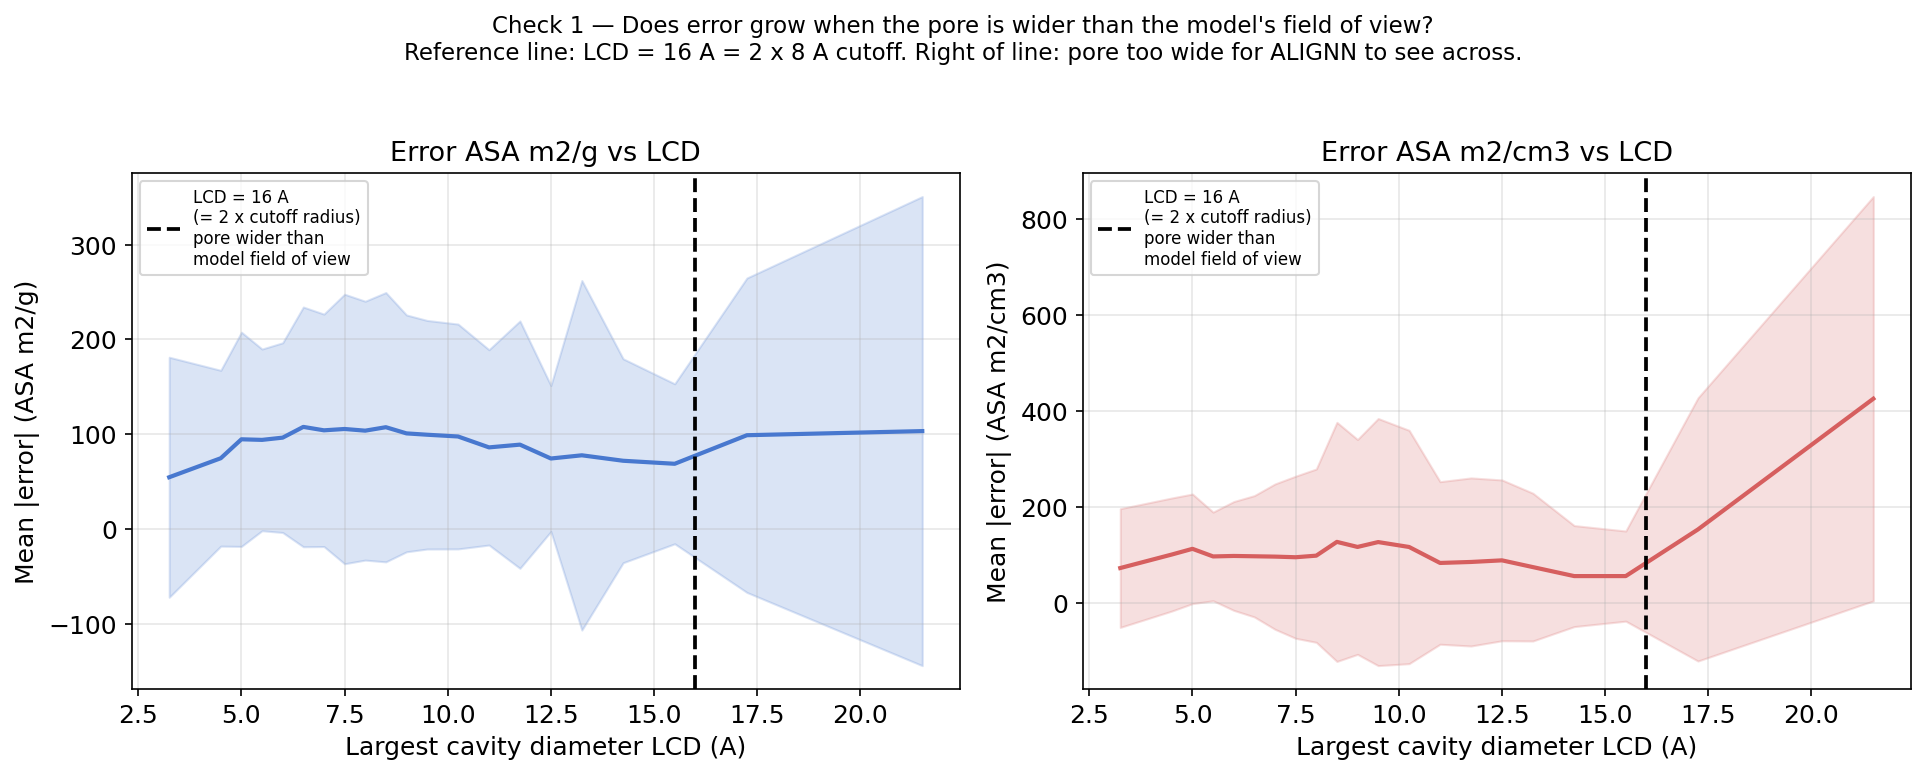

  Saved check1_lcd_vs_error.png

Generating Check 2 — Unit cell volume vs error, split by pore size...
  Small pore (LCD <= 16 A): 12,038 structures
  Large pore (LCD  > 16 A): 1,094 structures


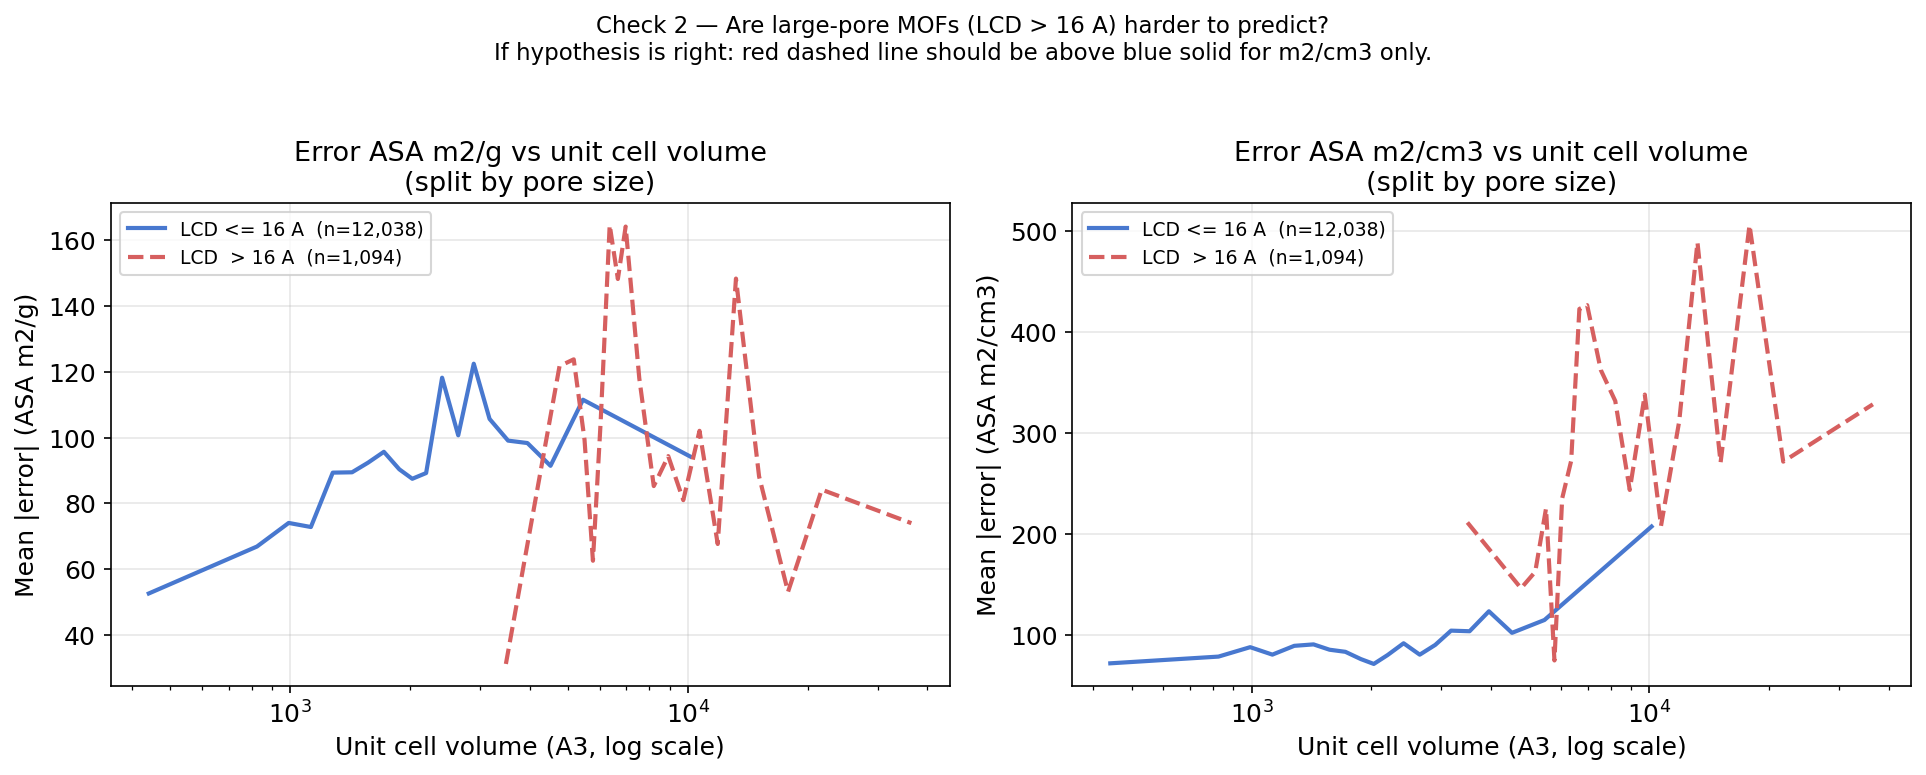

  Saved check2_unitcell_split_by_poresize.png

Generating Check 3 — Implied density error...


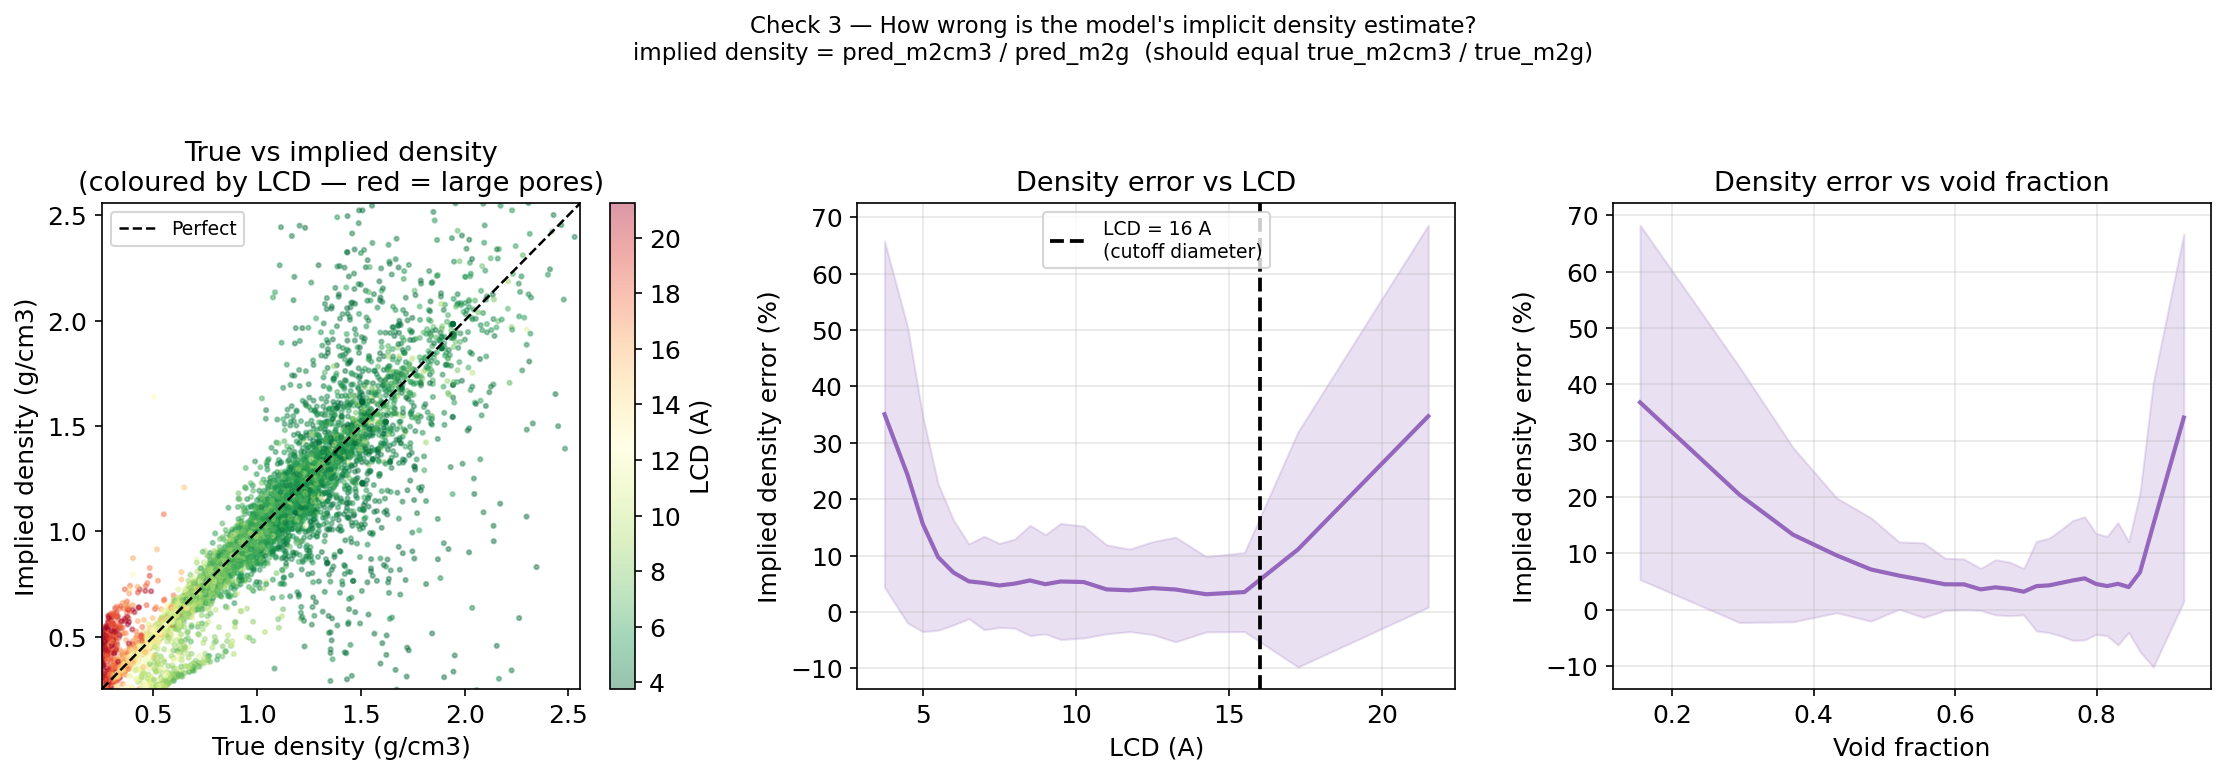

  Saved check3_implied_density_error_v2.png

EXTRA CHECKS SUMMARY

Check 1 — r(LCD, error):
  m2/g   : r = -0.013   (should be ~0)
  m2/cm3 : r = 0.185   (should be larger, positive)

Mean error split by pore size:
  LCD <= 16 A:  m2/g MAE = 92.1   m2/cm3 MAE = 95.2
  LCD  > 16 A:  m2/g MAE = 101.1   m2/cm3 MAE = 291.9

Check 3 — r(feature, implied density error %):
  LCD          : r = 0.056
  void fraction: r = -0.196

  Median density error: 3.0%
  Structures with >20% density error: 1,402 (10.8%)

All figures saved to ./asa_analysis_output/


In [ ]:
# EXTRA ANALYSIS v2

import os, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

OUTPUT_DIR = "./asa_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
})

ZIP_M2G   = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2g_alignn.zip")
ZIP_M2CM3 = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2cm3_alignn.zip")

CUTOFF_RADIUS  = 8.0          # A ALIGNN bond cutoff
LCD_THRESHOLD  = 2 * CUTOFF_RADIUS   # 16 A pore wider than model's diameter of vision

# Load prediction CSVs

print("Reading prediction CSVs from zip files...")
with zipfile.ZipFile(ZIP_M2G) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    df_m2g = pd.read_csv(io.BytesIO(zp.read(csv_name)),
                         names=["id","true_m2g","pred_m2g"], skiprows=1)

with zipfile.ZipFile(ZIP_M2CM3) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    df_m2cm3 = pd.read_csv(io.BytesIO(zp.read(csv_name)),
                            names=["id","true_m2cm3","pred_m2cm3"], skiprows=1)

for df in [df_m2g, df_m2cm3]:
    df["id"] = df["id"].astype(str).str.strip()

pred_df = df_m2g.merge(df_m2cm3, on="id")
print(f"  {len(pred_df)} structures with both predictions")

# Load hMOF + compute structural features

print("\nLoading hMOF dataset...")
from jarvis.db.figshare import data as jdata
raw = jdata("hmof")

records = []
for row in raw:
    try:
        lat     = np.array(row["atoms"]["lattice_mat"])
        vol     = abs(np.linalg.det(lat))
        n_atoms = len(row["atoms"]["elements"])
        records.append({
            "id":                 str(row["id"]),
            "surface_area_m2g":   float(row.get("surface_area_m2g",   np.nan)),
            "surface_area_m2cm3": float(row.get("surface_area_m2cm3", np.nan)),
            "void_fraction":      float(row.get("void_fraction",       np.nan)),
            "lcd":                float(row.get("lcd",                 np.nan)),
            "pld":                float(row.get("pld",                 np.nan)),
            "unit_cell_volume":   vol,
            "n_atoms":            n_atoms,
            "vol_per_atom":       vol / n_atoms,
        })
    except Exception:
        continue

hmof_df = pd.DataFrame(records).dropna(
    subset=["surface_area_m2g","surface_area_m2cm3","lcd"])
valid = hmof_df["surface_area_m2g"] > 0
hmof_df.loc[valid, "density"] = (
    hmof_df.loc[valid, "surface_area_m2cm3"] / hmof_df.loc[valid, "surface_area_m2g"]
)
hmof_df = hmof_df.dropna(subset=["density"])

merged = pred_df.merge(hmof_df, on="id", how="inner")
merged["err_m2g"]   = np.abs(merged["pred_m2g"]   - merged["true_m2g"])
merged["err_m2cm3"] = np.abs(merged["pred_m2cm3"] - merged["true_m2cm3"])

print(f"  {len(merged)} structures after merge")
print(f"\n  LCD stats in test set:")
print(f"    min={merged['lcd'].min():.1f} A,  "
      f"median={merged['lcd'].median():.1f} A,  "
      f"max={merged['lcd'].max():.1f} A")
print(f"    Structures with LCD > {LCD_THRESHOLD:.0f} A (pore wider than cutoff diameter): "
      f"{(merged['lcd'] > LCD_THRESHOLD).sum():,} "
      f"({100*(merged['lcd'] > LCD_THRESHOLD).mean():.1f}%)")

# Helper: binned error plot

def binned_error(ax, x, y, colour, n_bins=25, log_x=False):
    xp = np.log10(x) if log_x else x
    bins = np.unique(np.percentile(xp, np.linspace(0, 100, n_bins + 1)))
    bin_idx = np.clip(np.digitize(xp, bins) - 1, 0, len(bins) - 2)
    bm, bs, bc = [], [], []
    for b in range(len(bins) - 1):
        mask = bin_idx == b
        if mask.sum() < 10: continue
        vals = y[mask]
        bm.append(vals.mean()); bs.append(vals.std())
        bc.append((bins[b] + bins[b+1]) / 2)
    bm, bs, bc = np.array(bm), np.array(bs), np.array(bc)
    plot_x = 10**bc if log_x else bc
    ax.plot(plot_x, bm, color=colour, linewidth=2)
    ax.fill_between(plot_x, bm - bs, bm + bs, alpha=0.2, color=colour)
    #r, _ = stats.pearsonr(xp, y.fillna(0))
    #ax.text(0.03, 0.97, f"r = {r:.3f}", transform=ax.transAxes,
    #        ha="left", va="top", fontsize=10,
    #        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    #return r

# CHECK 1: LCD vs error (with LCD=16A reference line)
# This is the cleanest version of the cutoff argument:
# when LCD > 16 A the pore is wider than ALIGNN can see across.

print("\nGenerating Check 1 — LCD vs error (corrected reference line)...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, err_col, colour, label in [
    (axes[0], "err_m2g",   "#4878CF", "ASA m2/g"),
    (axes[1], "err_m2cm3", "#D65F5F", "ASA m2/cm3"),
]:
    binned_error(ax, merged["lcd"], merged[err_col], colour, log_x=False)

    ax.axvline(LCD_THRESHOLD, color="black", linestyle="--", linewidth=1.8,
               label=f"LCD = {LCD_THRESHOLD:.0f} A\n(= 2 x cutoff radius)\npore wider than\nmodel field of view")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_xlabel("Largest cavity diameter LCD (A)")
    ax.set_ylabel(f"Mean |error| ({label})")
    ax.set_title(f"Error {label} vs LCD")
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Check 1 — Does error grow when the pore is wider than the model's field of view?\n"
    f"Reference line: LCD = {LCD_THRESHOLD:.0f} A = 2 x {CUTOFF_RADIUS:.0f} A cutoff. "
    f"Right of line: pore too wide for ALIGNN to see across.",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "check1_lcd_vs_error.png"))
plt.show()
print("  Saved check1_lcd_vs_error.png")

# CHECK 2: Unit cell volume vs error (with LCD=16A colour split)
# Split structures into LCD <= 16A (small pores, model can see across)
# and LCD > 16A (large pores, model cannot see across).
# If the hypothesis is right, the large-pore group should have higher m2/cm3 error.

print("\nGenerating Check 2 — Unit cell volume vs error, split by pore size...")

small_pore = merged[merged["lcd"] <= LCD_THRESHOLD].copy()
large_pore = merged[merged["lcd"] >  LCD_THRESHOLD].copy()

print(f"  Small pore (LCD <= {LCD_THRESHOLD:.0f} A): {len(small_pore):,} structures")
print(f"  Large pore (LCD  > {LCD_THRESHOLD:.0f} A): {len(large_pore):,} structures")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, err_col, label in [
    (axes[0], "err_m2g",   "ASA m2/g"),
    (axes[1], "err_m2cm3", "ASA m2/cm3"),
]:
    for df_sub, colour, grp_label, ls in [
        (small_pore, "#4878CF", f"LCD <= {LCD_THRESHOLD:.0f} A  (n={len(small_pore):,})", "-"),
        (large_pore, "#D65F5F", f"LCD  > {LCD_THRESHOLD:.0f} A  (n={len(large_pore):,})", "--"),
    ]:
        if len(df_sub) < 20:
            continue
        log_vol = np.log10(df_sub["unit_cell_volume"])
        bins = np.unique(np.percentile(log_vol, np.linspace(0, 100, 21)))
        bin_idx = np.clip(np.digitize(log_vol, bins) - 1, 0, len(bins) - 2)
        bm, bc = [], []
        for b in range(len(bins) - 1):
            mask = bin_idx == b
            if mask.sum() < 5: continue
            bm.append(df_sub.loc[mask, err_col].mean())
            bc.append((bins[b] + bins[b+1]) / 2)
        ax.plot(10**np.array(bc), bm, color=colour, linestyle=ls,
                linewidth=2, label=grp_label)

    ax.set_xscale("log")
    ax.set_xlabel("Unit cell volume (A3, log scale)")
    ax.set_ylabel(f"Mean |error| ({label})")
    ax.set_title(f"Error {label} vs unit cell volume\n(split by pore size)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Check 2 — Are large-pore MOFs (LCD > {LCD_THRESHOLD:.0f} A) harder to predict?\n"
    "If hypothesis is right: red dashed line should be above blue solid for m2/cm3 only.",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "check2_unitcell_split_by_poresize.png"))
plt.show()
print("  Saved check2_unitcell_split_by_poresize.png")

# Implied density error vs LCD (with reference line)

print("\nGenerating Check 3 — Implied density error...")

valid = (merged["pred_m2g"].abs() > 10) & (merged["true_m2g"].abs() > 10)
df3 = merged[valid].copy()
df3["true_density"]      = df3["true_m2cm3"]  / df3["true_m2g"]
df3["implied_density"]   = df3["pred_m2cm3"]  / df3["pred_m2g"]
df3["density_error"]     = np.abs(df3["implied_density"] - df3["true_density"])
df3["density_error_pct"] = (df3["density_error"] / df3["true_density"].abs()) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: implied vs true density coloured by LCD
ax = axes[0]
norm = mcolors.Normalize(vmin=df3["lcd"].quantile(0.02),
                         vmax=df3["lcd"].quantile(0.98))
sc = ax.scatter(df3["true_density"], df3["implied_density"],
                c=df3["lcd"], cmap="RdYlGn_r",
                norm=norm, s=4, alpha=0.4, rasterized=True)
plt.colorbar(sc, ax=ax, label="LCD (A)")
lo = min(df3["true_density"].quantile(0.01), df3["implied_density"].quantile(0.01))
hi = max(df3["true_density"].quantile(0.99), df3["implied_density"].quantile(0.99))
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="Perfect")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("True density (g/cm3)"); ax.set_ylabel("Implied density (g/cm3)")
ax.set_title("True vs implied density\n(coloured by LCD — red = large pores)")
ax.legend(fontsize=9)

# Panel 2: density error % vs LCD with reference line
ax = axes[1]
binned_error(ax, df3["lcd"], df3["density_error_pct"].clip(0, 100),
             "#9467BD", log_x=False)
ax.axvline(LCD_THRESHOLD, color="black", linestyle="--", linewidth=1.8,
           label=f"LCD = {LCD_THRESHOLD:.0f} A\n(cutoff diameter)")
ax.set_xlabel("LCD (A)"); ax.set_ylabel("Implied density error (%)")
ax.set_title(f"Density error vs LCD")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3: density error % vs void fraction with reference line
ax = axes[2]
binned_error(ax, df3["void_fraction"],
             df3["density_error_pct"].clip(0, 100), "#9467BD", log_x=False)
ax.set_xlabel("Void fraction"); ax.set_ylabel("Implied density error (%)")
ax.set_title("Density error vs void fraction")
ax.grid(True, alpha=0.3)

fig.suptitle(
    "Check 3 — How wrong is the model's implicit density estimate?\n"
    "implied density = pred_m2cm3 / pred_m2g  (should equal true_m2cm3 / true_m2g)",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "check3_implied_density_error_v2.png"))
plt.show()
print("  Saved check3_implied_density_error_v2.png")

# SUMMARY

print("\n" + "="*65)
print("EXTRA CHECKS SUMMARY")
print("="*65)

r_lcd_m2g,   _ = stats.pearsonr(merged["lcd"], merged["err_m2g"].fillna(0))
r_lcd_m2cm3, _ = stats.pearsonr(merged["lcd"], merged["err_m2cm3"].fillna(0))

r3_lcd, _ = stats.pearsonr(df3["lcd"],
                             df3["density_error_pct"].clip(0,100).fillna(0))
r3_vf,  _ = stats.pearsonr(df3["void_fraction"],
                             df3["density_error_pct"].clip(0,100).fillna(0))

print(f"\nCheck 1 — r(LCD, error):")
print(f"  m2/g   : r = {r_lcd_m2g:.3f}   (should be ~0)")
print(f"  m2/cm3 : r = {r_lcd_m2cm3:.3f}   (should be larger, positive)")

print(f"\nMean error split by pore size:")
for grp, label in [(small_pore, f"LCD <= {LCD_THRESHOLD:.0f} A"),
                    (large_pore, f"LCD  > {LCD_THRESHOLD:.0f} A")]:
    print(f"  {label}:  "
          f"m2/g MAE = {grp['err_m2g'].mean():.1f}   "
          f"m2/cm3 MAE = {grp['err_m2cm3'].mean():.1f}")

print(f"\nCheck 3 — r(feature, implied density error %):")
print(f"  LCD          : r = {r3_lcd:.3f}")
print(f"  void fraction: r = {r3_vf:.3f}")
print(f"\n  Median density error: {df3['density_error_pct'].median():.1f}%")
print(f"  Structures with >20% density error: "
      f"{(df3['density_error_pct'] > 20).sum():,} "
      f"({100*(df3['density_error_pct'] > 20).mean():.1f}%)")

print(f"\nAll figures saved to {OUTPUT_DIR}/")

Reading prediction CSVs from zip files...
  13765 structures with both predictions
Loading hMOF dataset...
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
  13132 structures after merge
  Small pore: 12,038  Large pore: 1,094

Generating Figure A — LCD distribution...


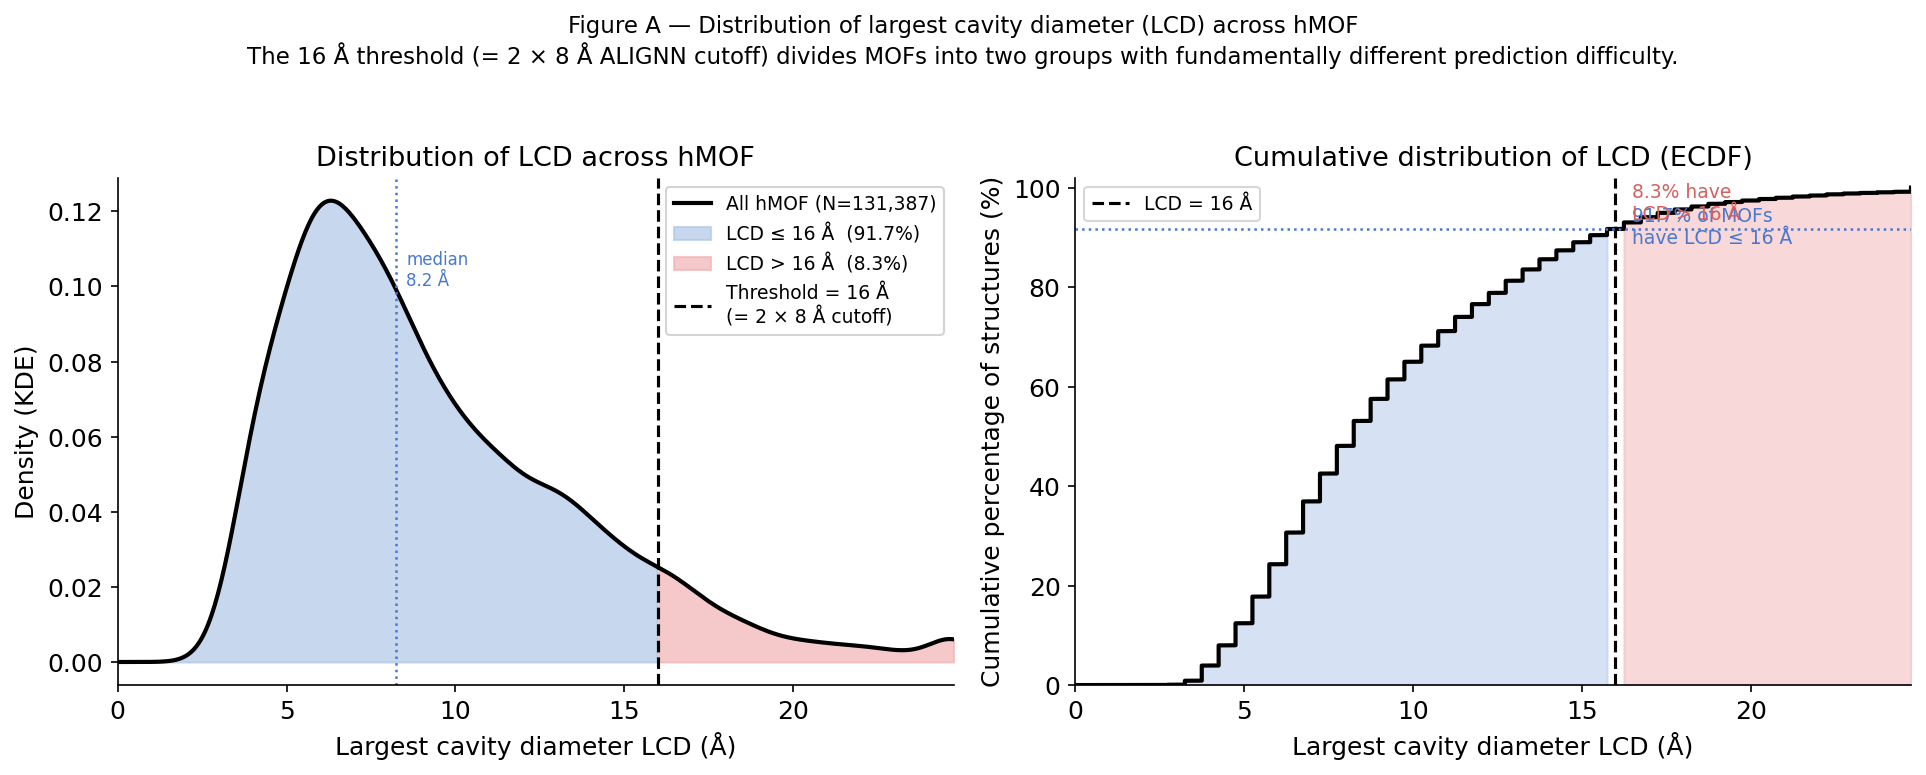

  Saved figA_lcd_distribution.png

Generating Figure B — Violin plots of error by LCD bin...


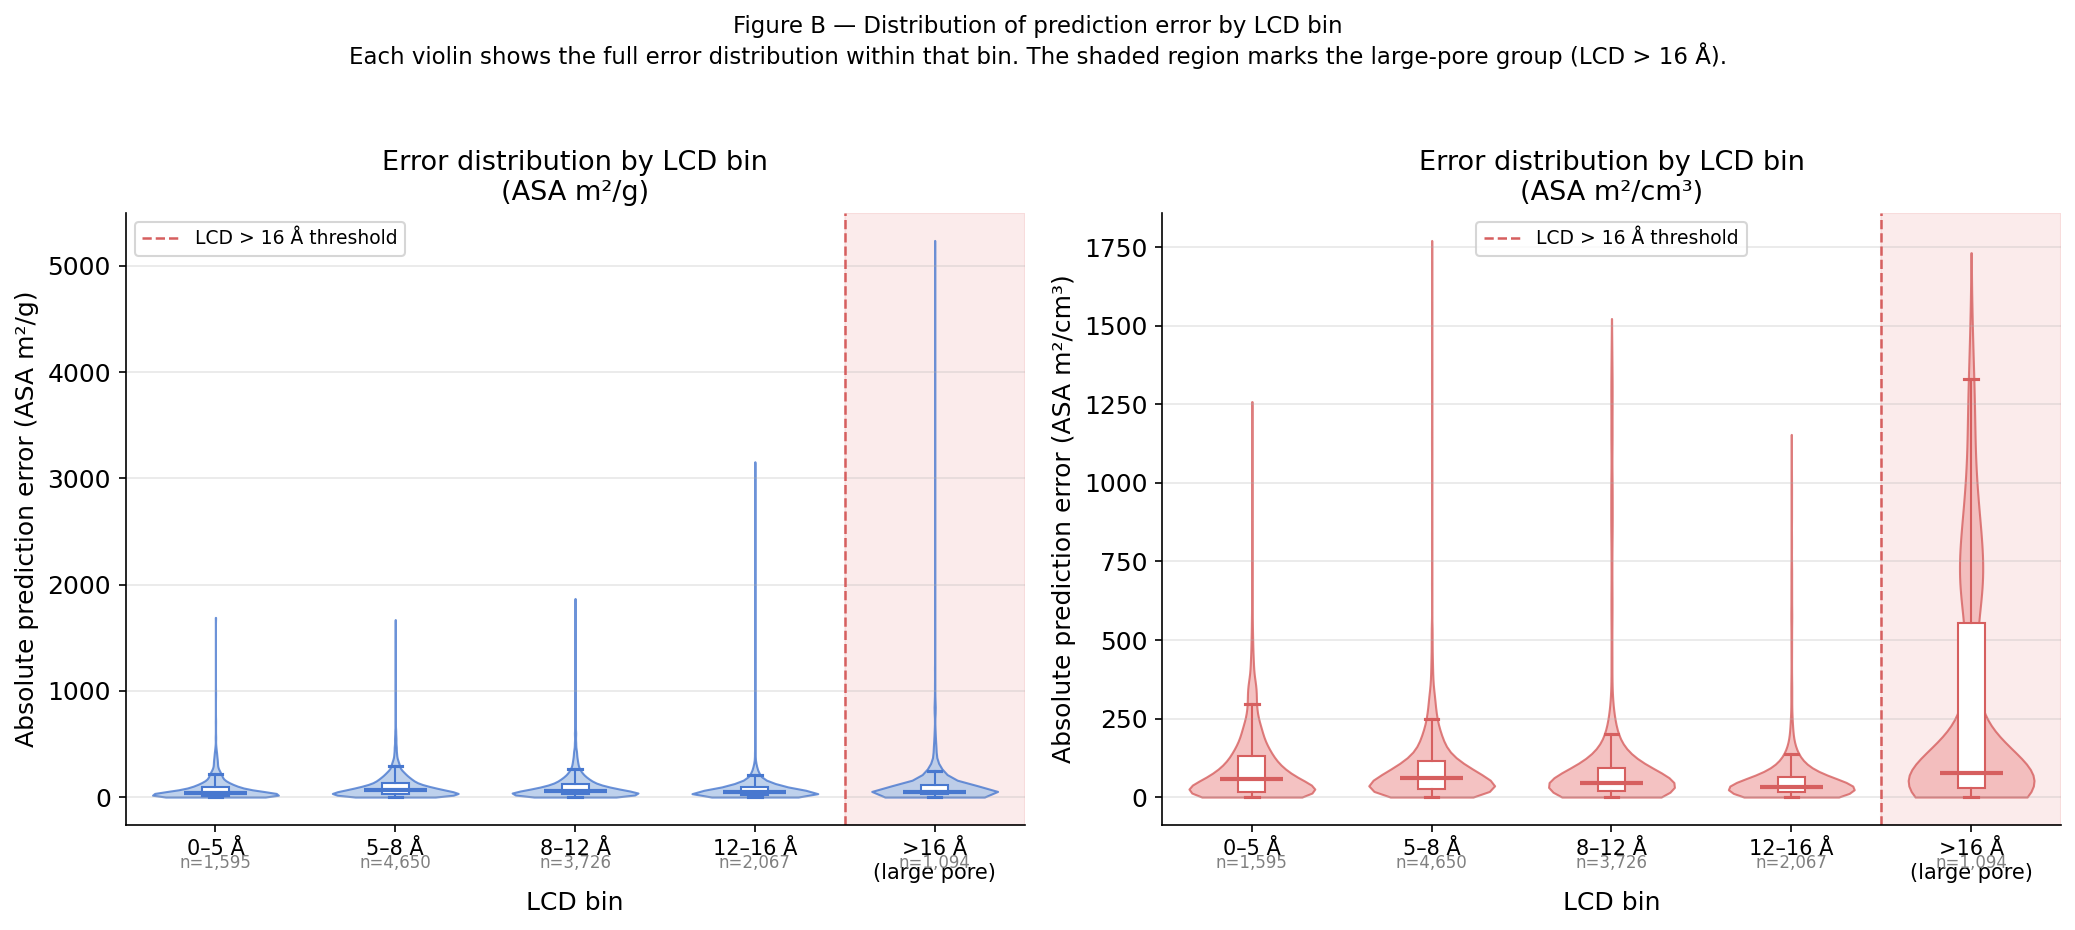

  Saved figB_violin_error_by_lcd.png

Generating Figure C — Unit cell volume distribution...


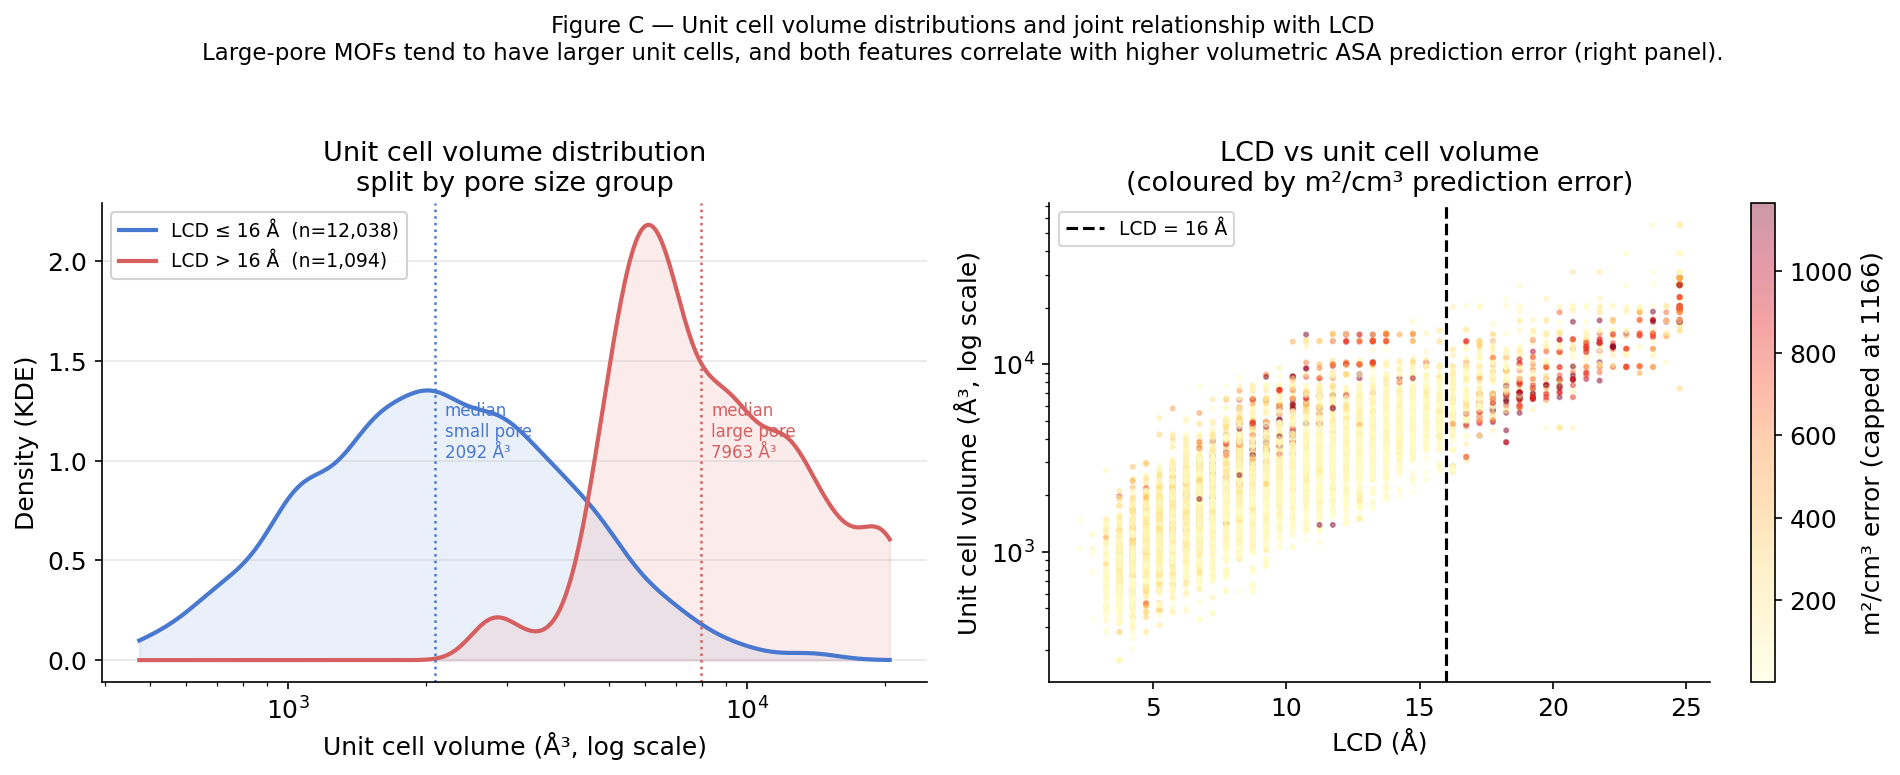

  Saved figC_unitcell_volume_distribution.png

STATISTICAL SUMMARY BY PORE GROUP

Small pore (LCD ≤ 16 Å)  (n = 12,038)
  MAE m2/g  : mean=92.1  median=56.7  std=123.7  p75=116.4  p95=288.9
  MAE m2/cm3: mean=95.2  median=48.0  std=168.8  p75=100.5  p95=305.0
  LCD     : mean=8.4 Å  median=7.8 Å
  Vol     : mean=2620 Å³  median=2092 Å³

Large pore (LCD  > 16 Å)  (n = 1,094)
  MAE m2/g  : mean=101.1  median=52.0  std=211.6  p75=112.2  p95=307.9
  MAE m2/cm3: mean=291.9  median=76.7  std=382.3  p75=554.2  p95=1098.4
  LCD     : mean=19.1 Å  median=18.2 Å
  Vol     : mean=10349 Å³  median=7963 Å³

All figures saved to ./asa_analysis_output/


In [ ]:
import os, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import gaussian_kde
from jarvis.db.figshare import data as jdata

OUTPUT_DIR = "./asa_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})

ZIP_M2G   = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2g_alignn.zip")
ZIP_M2CM3 = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2cm3_alignn.zip")
LCD_THRESHOLD = 16.0   # Angstroms

# Load prediction CSVs

print("Reading prediction CSVs from zip files...")
with zipfile.ZipFile(ZIP_M2G) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    df_m2g = pd.read_csv(io.BytesIO(zp.read(csv_name)),
                         names=["id","true_m2g","pred_m2g"], skiprows=1)

with zipfile.ZipFile(ZIP_M2CM3) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    df_m2cm3 = pd.read_csv(io.BytesIO(zp.read(csv_name)),
                            names=["id","true_m2cm3","pred_m2cm3"], skiprows=1)

for df in [df_m2g, df_m2cm3]:
    df["id"] = df["id"].astype(str).str.strip()

pred_df = df_m2g.merge(df_m2cm3, on="id")
print(f"  {len(pred_df)} structures with both predictions")

# Load hMOF

print("Loading hMOF dataset...")
raw = jdata("hmof")

records = []
for row in raw:
    try:
        lat     = np.array(row["atoms"]["lattice_mat"])
        vol     = abs(np.linalg.det(lat))
        n_atoms = len(row["atoms"]["elements"])
        records.append({
            "id":                 str(row["id"]),
            "surface_area_m2g":   float(row.get("surface_area_m2g",   np.nan)),
            "surface_area_m2cm3": float(row.get("surface_area_m2cm3", np.nan)),
            "void_fraction":      float(row.get("void_fraction",       np.nan)),
            "lcd":                float(row.get("lcd",                 np.nan)),
            "pld":                float(row.get("pld",                 np.nan)),
            "unit_cell_volume":   vol,
            "n_atoms":            n_atoms,
        })
    except Exception:
        continue

hmof_df = pd.DataFrame(records).dropna(
    subset=["surface_area_m2g","surface_area_m2cm3","lcd"])
valid = hmof_df["surface_area_m2g"] > 0
hmof_df.loc[valid, "density"] = (
    hmof_df.loc[valid, "surface_area_m2cm3"] / hmof_df.loc[valid, "surface_area_m2g"]
)
hmof_df = hmof_df.dropna(subset=["density"])

# Merge with predictions
merged = pred_df.merge(hmof_df, on="id", how="inner")
merged["err_m2g"]   = np.abs(merged["pred_m2g"]   - merged["true_m2g"])
merged["err_m2cm3"] = np.abs(merged["pred_m2cm3"] - merged["true_m2cm3"])

# Pore size groups
merged["pore_group"] = np.where(
    merged["lcd"] <= LCD_THRESHOLD, f"Small pore\n(LCD ≤ {LCD_THRESHOLD:.0f} Å)",
                                    f"Large pore\n(LCD > {LCD_THRESHOLD:.0f} Å)"
)

print(f"  {len(merged)} structures after merge")
print(f"  Small pore: {(merged['lcd'] <= LCD_THRESHOLD).sum():,}  "
      f"Large pore: {(merged['lcd'] > LCD_THRESHOLD).sum():,}")

# Colour palette — consistent across all figures
C_SMALL  = "#4878CF"   # blue  — small pore / m2/g
C_LARGE  = "#D65F5F"   # red   — large pore / m2/cm3
C_FILL_S = "#AEC6E8"   # light blue fill
C_FILL_L = "#F2B3B3"   # light red fill

# LCD distribution across the full hMOF dataset
print("\nGenerating Figure A — LCD distribution...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lcd_all = hmof_df["lcd"].dropna()
lcd_test_small = merged.loc[merged["lcd"] <= LCD_THRESHOLD, "lcd"]
lcd_test_large = merged.loc[merged["lcd"] >  LCD_THRESHOLD, "lcd"]

# Left: KDE with shaded groups
ax = axes[0]
x_range = np.linspace(lcd_all.min(), lcd_all.max(), 500)

kde_all = gaussian_kde(lcd_all, bw_method=0.15)
y_all   = kde_all(x_range)

ax.plot(x_range, y_all, color="black", linewidth=2, label="All hMOF (N=131,387)")
ax.fill_between(x_range, y_all,
                where=(x_range <= LCD_THRESHOLD),
                color=C_FILL_S, alpha=0.7,
                label=f"LCD ≤ {LCD_THRESHOLD:.0f} Å  "
                      f"({100*(lcd_all <= LCD_THRESHOLD).mean():.1f}%)")
ax.fill_between(x_range, y_all,
                where=(x_range > LCD_THRESHOLD),
                color=C_FILL_L, alpha=0.7,
                label=f"LCD > {LCD_THRESHOLD:.0f} Å  "
                      f"({100*(lcd_all > LCD_THRESHOLD).mean():.1f}%)")
ax.axvline(LCD_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold = {LCD_THRESHOLD:.0f} Å\n(= 2 × 8 Å cutoff)")

ax.set_xlabel("Largest cavity diameter LCD (Å)")
ax.set_ylabel("Density (KDE)")
ax.set_title("Distribution of LCD across hMOF")
ax.legend(fontsize=9, framealpha=0.85)
ax.set_xlim(0, lcd_all.quantile(0.995))

# Annotate with median and mean
ax.axvline(lcd_all.median(), color=C_SMALL, linestyle=":", linewidth=1.2)
ax.text(lcd_all.median() + 0.3, ax.get_ylim()[1] * 0.85,
        f"median\n{lcd_all.median():.1f} Å",
        color=C_SMALL, fontsize=8, va="top")

# Right: ECDF
ax = axes[1]
lcd_sorted = np.sort(lcd_all)
ecdf = np.arange(1, len(lcd_sorted) + 1) / len(lcd_sorted)

ax.plot(lcd_sorted, ecdf * 100, color="black", linewidth=2)
ax.axvline(LCD_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"LCD = {LCD_THRESHOLD:.0f} Å")
pct_below = 100 * (lcd_all <= LCD_THRESHOLD).mean()
ax.axhline(pct_below, color=C_SMALL, linestyle=":", linewidth=1.2)
ax.fill_between(lcd_sorted, ecdf * 100,
                where=(lcd_sorted <= LCD_THRESHOLD),
                color=C_FILL_S, alpha=0.5)
ax.fill_between(lcd_sorted, ecdf * 100,
                where=(lcd_sorted > LCD_THRESHOLD),
                alpha=0.5, color=C_FILL_L)

ax.text(LCD_THRESHOLD + 0.5, pct_below - 3,
        f"{pct_below:.1f}% of MOFs\nhave LCD ≤ {LCD_THRESHOLD:.0f} Å",
        fontsize=9, color=C_SMALL)
ax.text(LCD_THRESHOLD + 0.5, pct_below + 2,
        f"{100 - pct_below:.1f}% have\nLCD > {LCD_THRESHOLD:.0f} Å",
        fontsize=9, color=C_LARGE)

ax.set_xlabel("Largest cavity diameter LCD (Å)")
ax.set_ylabel("Cumulative percentage of structures (%)")
ax.set_title("Cumulative distribution of LCD (ECDF)")
ax.set_xlim(0, lcd_all.quantile(0.995))
ax.set_ylim(0, 102)
ax.legend(fontsize=9)

fig.suptitle(
    "Figure A — Distribution of largest cavity diameter (LCD) across hMOF\n"
    f"The 16 Å threshold (= 2 × 8 Å ALIGNN cutoff) divides MOFs into "
    f"two groups with fundamentally different prediction difficulty.",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figA_lcd_distribution.png"))
plt.show()
print("  Saved figA_lcd_distribution.png")


# Violin plots: error distribution by LCD bin

print("\nGenerating Figure B — Violin plots of error by LCD bin...")

# Define LCD bins with the threshold as a natural break point
bin_edges  = [0, 5, 8, 12, LCD_THRESHOLD, merged["lcd"].max() + 1]
bin_labels = ["0–5 Å", "5–8 Å", "8–12 Å", f"12–{LCD_THRESHOLD:.0f} Å",
              f">{LCD_THRESHOLD:.0f} Å\n(large pore)"]
merged["lcd_bin"] = pd.cut(merged["lcd"], bins=bin_edges, labels=bin_labels,
                            right=True, include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, err_col, colour, fill, label in [
    (axes[0], "err_m2g",   C_SMALL, C_FILL_S, "ASA m²/g"),
    (axes[1], "err_m2cm3", C_LARGE, C_FILL_L, "ASA m²/cm³"),
]:
    groups      = [merged.loc[merged["lcd_bin"] == b, err_col].dropna().values
                   for b in bin_labels]
    positions   = list(range(1, len(bin_labels) + 1))
    n_per_group = [len(g) for g in groups]

    # Violin plot
    parts = ax.violinplot(groups, positions=positions,
                          showmedians=True, showextrema=False,
                          widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor(fill)
        pc.set_edgecolor(colour)
        pc.set_alpha(0.8)
    parts["cmedians"].set_color(colour)
    parts["cmedians"].set_linewidth(2)

    # Overlay box plot for quartiles
    bp = ax.boxplot(groups, positions=positions, widths=0.15,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color=colour, linewidth=2),
                    boxprops=dict(facecolor="white", edgecolor=colour),
                    whiskerprops=dict(color=colour, linewidth=1),
                    capprops=dict(color=colour, linewidth=1.5))

    # Shade the large-pore bin differently to highlight it
    ax.axvspan(len(bin_labels) - 0.5, len(bin_labels) + 0.5,
               color=C_FILL_L, alpha=0.25, zorder=0)
    ax.axvline(len(bin_labels) - 0.5, color=C_LARGE, linestyle="--",
               linewidth=1.2, label=f"LCD > {LCD_THRESHOLD:.0f} Å threshold")

    ax.set_xticks(positions)
    ax.set_xticklabels(bin_labels, fontsize=10)
    ax.set_xlabel("LCD bin")
    ax.set_ylabel(f"Absolute prediction error ({label})")
    ax.set_title(f"Error distribution by LCD bin\n({label})")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Annotate with sample size
    for pos, n in zip(positions, n_per_group):
        ax.text(pos, ax.get_ylim()[0] - ax.get_ylim()[1] * 0.05,
                f"n={n:,}", ha="center", va="top", fontsize=8, color="gray")

fig.suptitle(
    "Figure B — Distribution of prediction error by LCD bin\n"
    "Each violin shows the full error distribution within that bin. "
    "The shaded region marks the large-pore group (LCD > 16 Å).",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figB_violin_error_by_lcd.png"))
plt.show()
print("  Saved figB_violin_error_by_lcd.png")

# Unit cell volume distribution

print("\nGenerating Figure C — Unit cell volume distribution...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# log-scale KDE split by pore size
ax = axes[0]
log_vol_small = np.log10(merged.loc[merged["lcd"] <= LCD_THRESHOLD, "unit_cell_volume"])
log_vol_large = np.log10(merged.loc[merged["lcd"] >  LCD_THRESHOLD, "unit_cell_volume"])

x_log = np.linspace(
    np.log10(merged["unit_cell_volume"].quantile(0.005)),
    np.log10(merged["unit_cell_volume"].quantile(0.995)),
    400
)

for log_vals, colour, fill, label in [
    (log_vol_small, C_SMALL, C_FILL_S, f"LCD ≤ {LCD_THRESHOLD:.0f} Å  (n={len(log_vol_small):,})"),
    (log_vol_large, C_LARGE, C_FILL_L, f"LCD > {LCD_THRESHOLD:.0f} Å  (n={len(log_vol_large):,})"),
]:
    kde  = gaussian_kde(log_vals, bw_method=0.2)
    y    = kde(x_log)
    ax.plot(10**x_log, y, color=colour, linewidth=2, label=label)
    ax.fill_between(10**x_log, y, alpha=0.25, color=fill)

ax.set_xscale("log")
ax.set_xlabel("Unit cell volume (Å³, log scale)")
ax.set_ylabel("Density (KDE)")
ax.set_title("Unit cell volume distribution\nsplit by pore size group")
ax.legend(fontsize=9, framealpha=0.85)
ax.grid(axis="y", alpha=0.3)

# Annotate medians
for log_vals, colour, label in [
    (log_vol_small, C_SMALL, "median\nsmall pore"),
    (log_vol_large, C_LARGE, "median\nlarge pore"),
]:
    med = 10**log_vals.median()
    ax.axvline(med, color=colour, linestyle=":", linewidth=1.2)
    ax.text(med * 1.05, ax.get_ylim()[1] * 0.5,
            f"{label}\n{med:.0f} Å³",
            color=colour, fontsize=8, va="center")

# LCD vs unit cell volume, coloured by m2/cm3 error
ax = axes[1]
# Cap error at 99th percentile for colour scale clarity
err_cap = merged["err_m2cm3"].quantile(0.99)
sc = ax.scatter(
    merged["lcd"],
    merged["unit_cell_volume"],
    c=merged["err_m2cm3"].clip(upper=err_cap),
    cmap="YlOrRd", s=4, alpha=0.4, rasterized=True
)
plt.colorbar(sc, ax=ax, label=f"m²/cm³ error (capped at {err_cap:.0f})")
ax.axvline(LCD_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"LCD = {LCD_THRESHOLD:.0f} Å")
ax.set_yscale("log")
ax.set_xlabel("LCD (Å)")
ax.set_ylabel("Unit cell volume (Å³, log scale)")
ax.set_title("LCD vs unit cell volume\n(coloured by m²/cm³ prediction error)")
ax.legend(fontsize=9)

fig.suptitle(
    "Figure C — Unit cell volume distributions and joint relationship with LCD\n"
    "Large-pore MOFs tend to have larger unit cells, and both features "
    "correlate with higher volumetric ASA prediction error (right panel).",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figC_unitcell_volume_distribution.png"))
plt.show()
print("  Saved figC_unitcell_volume_distribution.png")

# SUMMARY

print("\n" + "="*65)
print("STATISTICAL SUMMARY BY PORE GROUP")
print("="*65)

for grp_label, mask in [
    (f"Small pore (LCD ≤ {LCD_THRESHOLD:.0f} Å)", merged["lcd"] <= LCD_THRESHOLD),
    (f"Large pore (LCD  > {LCD_THRESHOLD:.0f} Å)", merged["lcd"] >  LCD_THRESHOLD),
]:
    g = merged[mask]
    print(f"\n{grp_label}  (n = {len(g):,})")
    for col, label in [("err_m2g",   "MAE m2/g  "),
                        ("err_m2cm3", "MAE m2/cm3")]:
        e = g[col]
        print(f"  {label}: mean={e.mean():.1f}  median={e.median():.1f}  "
              f"std={e.std():.1f}  p75={e.quantile(0.75):.1f}  "
              f"p95={e.quantile(0.95):.1f}")
    print(f"  LCD     : mean={g['lcd'].mean():.1f} Å  "
          f"median={g['lcd'].median():.1f} Å")
    print(f"  Vol     : mean={g['unit_cell_volume'].mean():.0f} Å³  "
          f"median={g['unit_cell_volume'].median():.0f} Å³")

print(f"\nAll figures saved to {OUTPUT_DIR}/")

Reading prediction CSVs from zip files...
  13765 structures with both predictions
Loading hMOF dataset...
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.

High void fraction (VF >= 0.75) structures: 4,918
  Overpredicted  (pred > true): 2,297  (46.7%)
  Underpredicted (pred < true): 2,621  (53.3%)

Generating Figure 1 — signed error distributions...


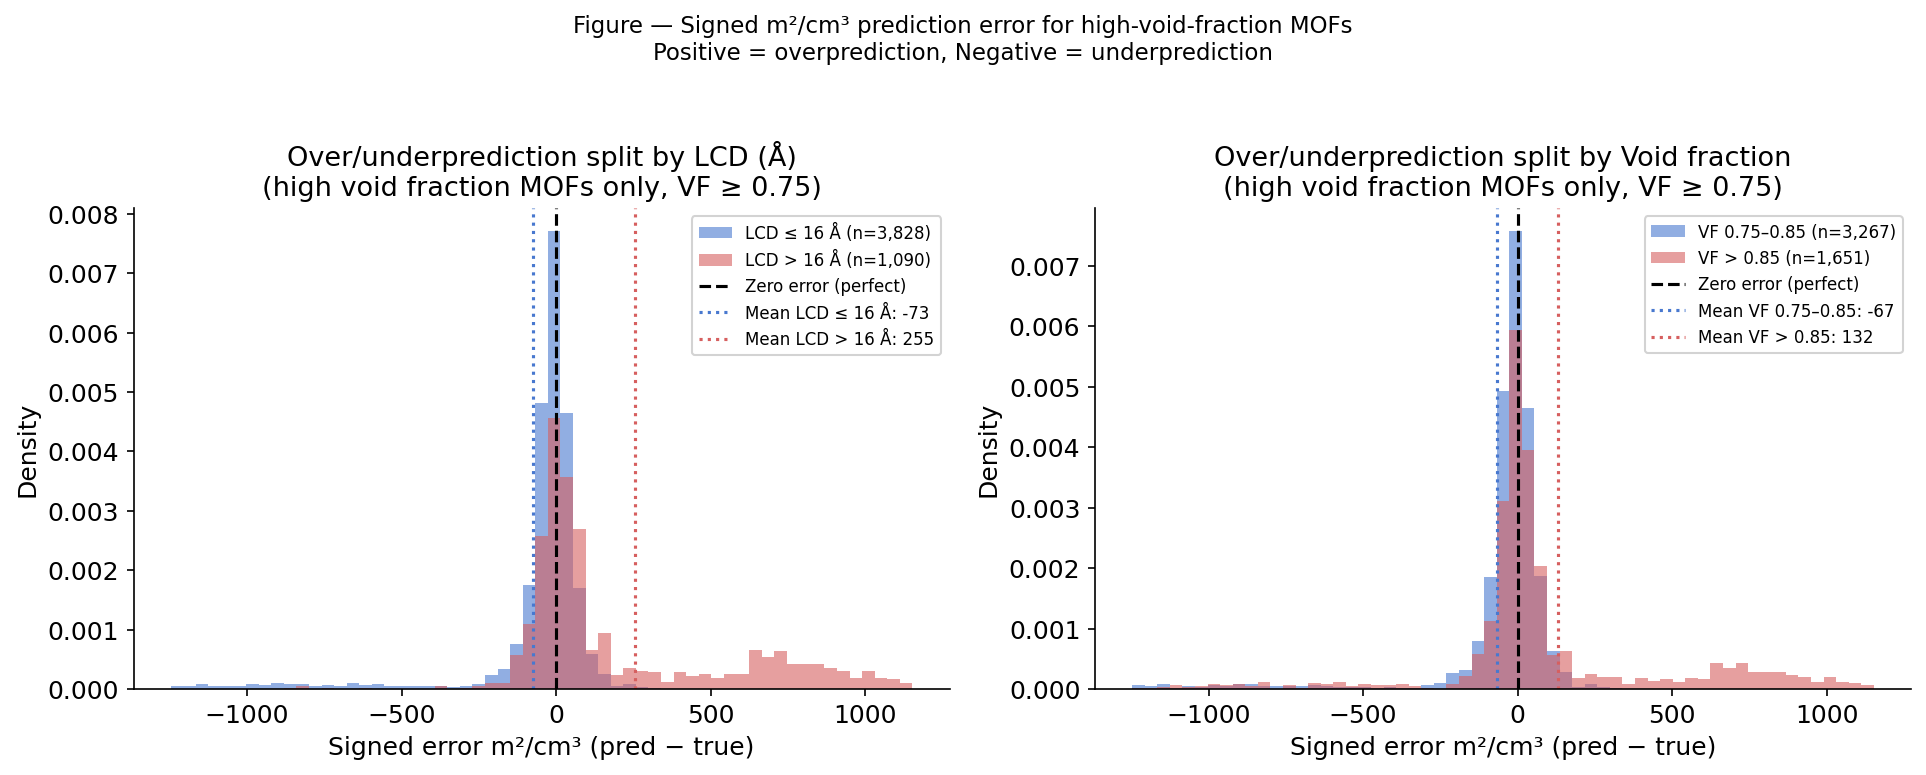

  Saved overunder_fig1_signed_error_dist.png
Generating Figure 2 — feature comparison over vs underpredicted...


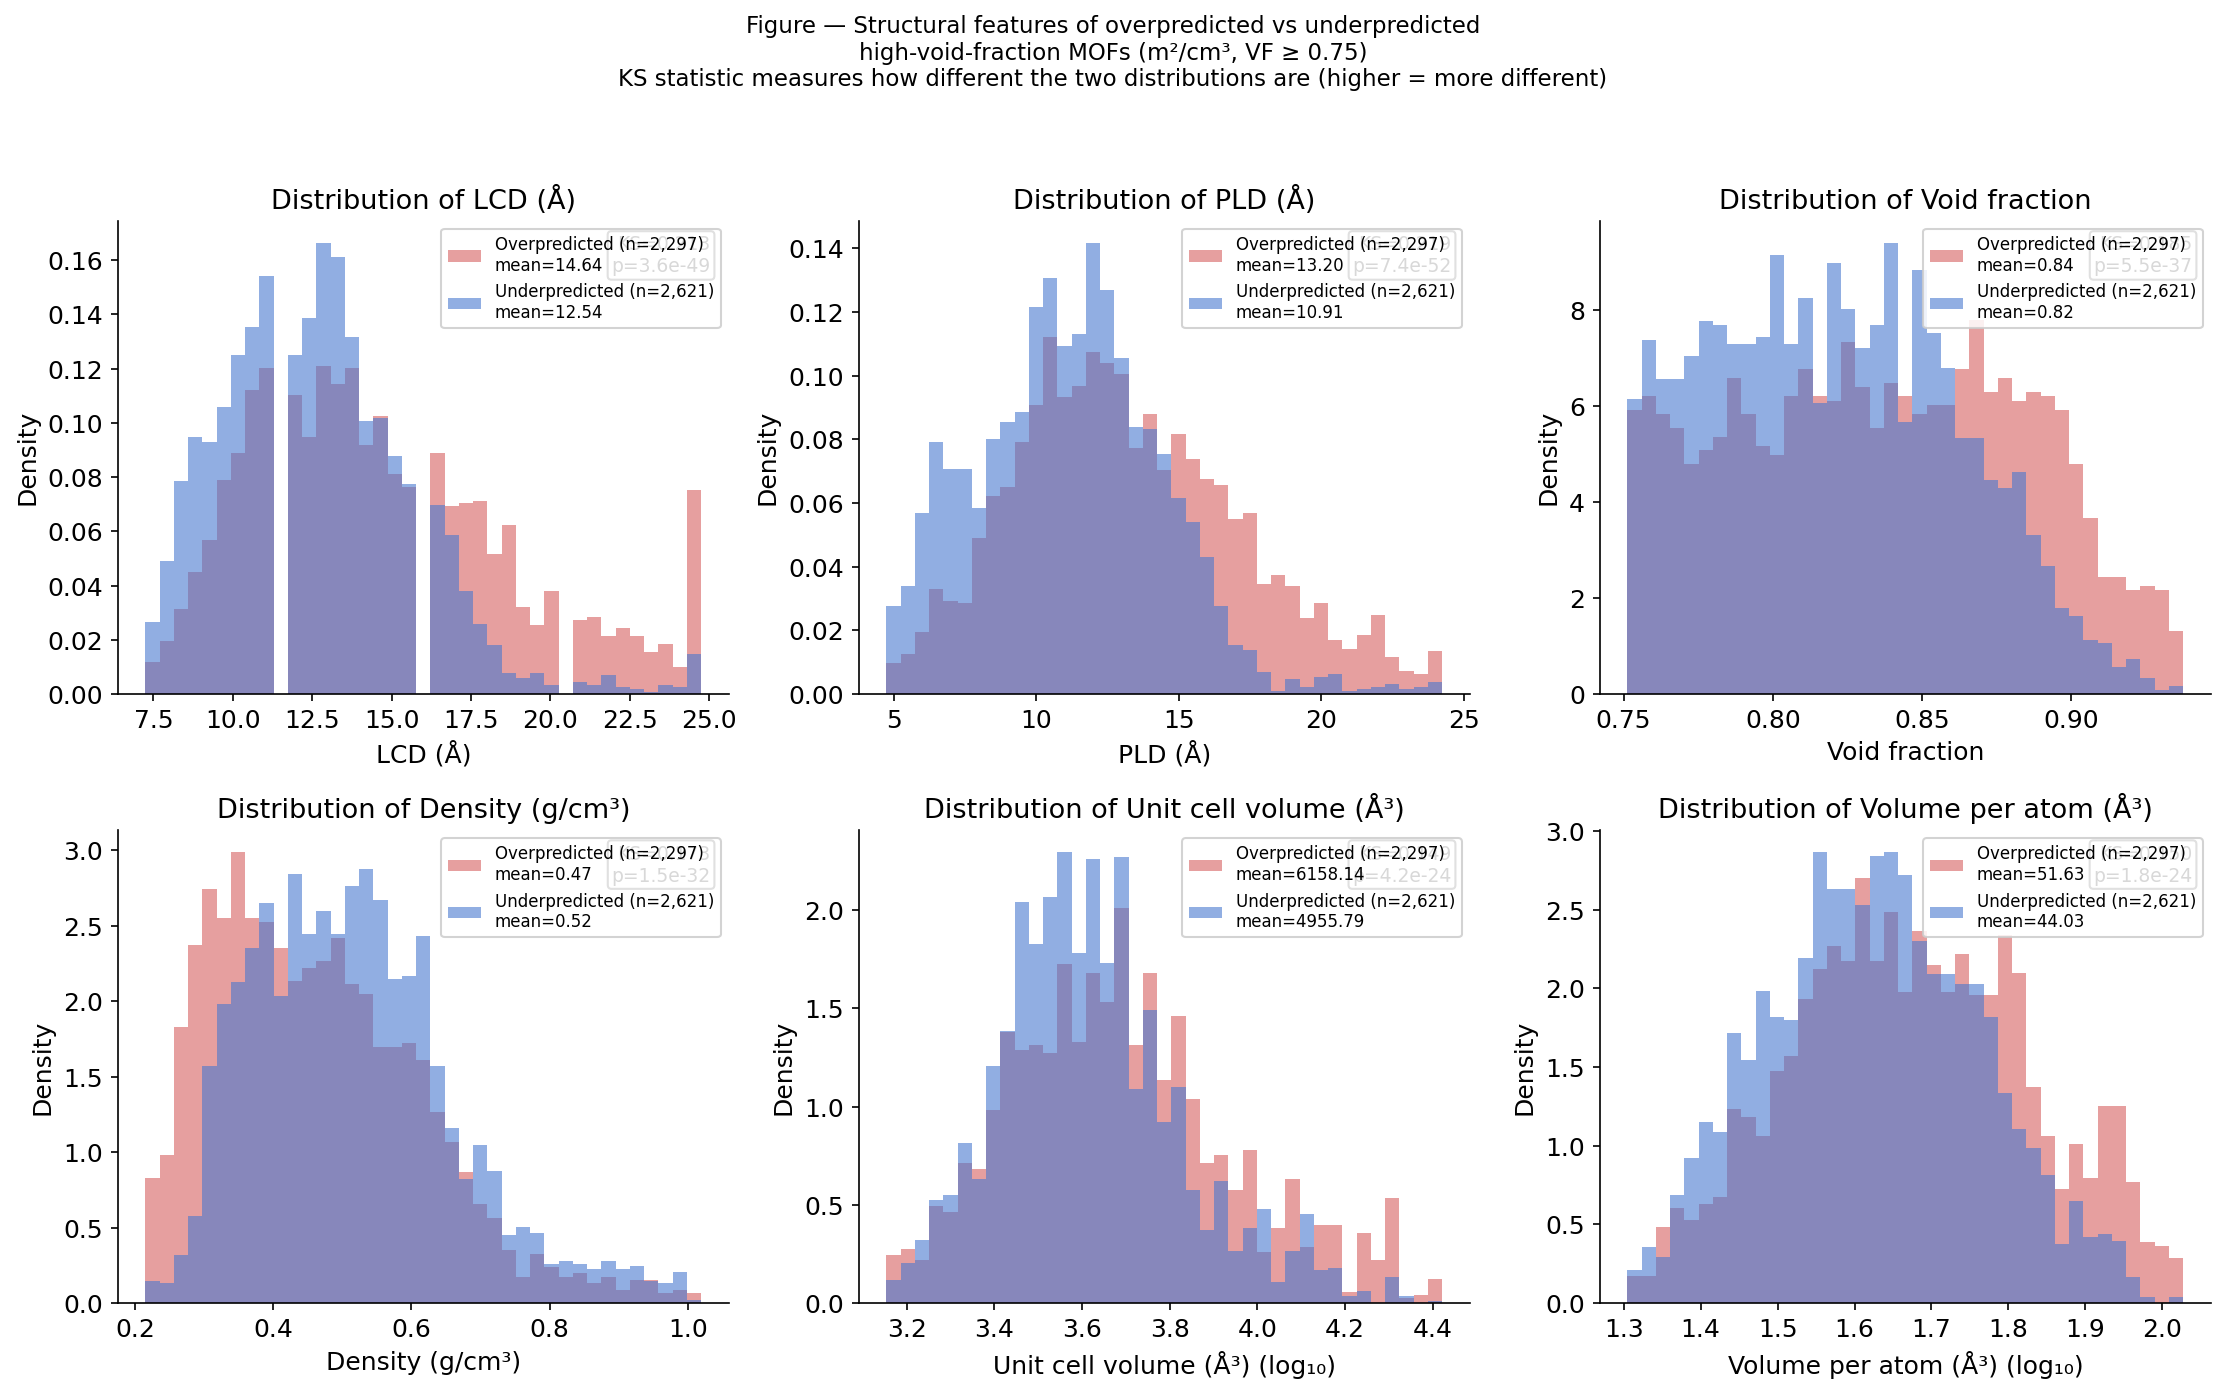

  Saved overunder_fig2_feature_comparison.png
Generating Figure 3 — parity plot coloured by error direction...


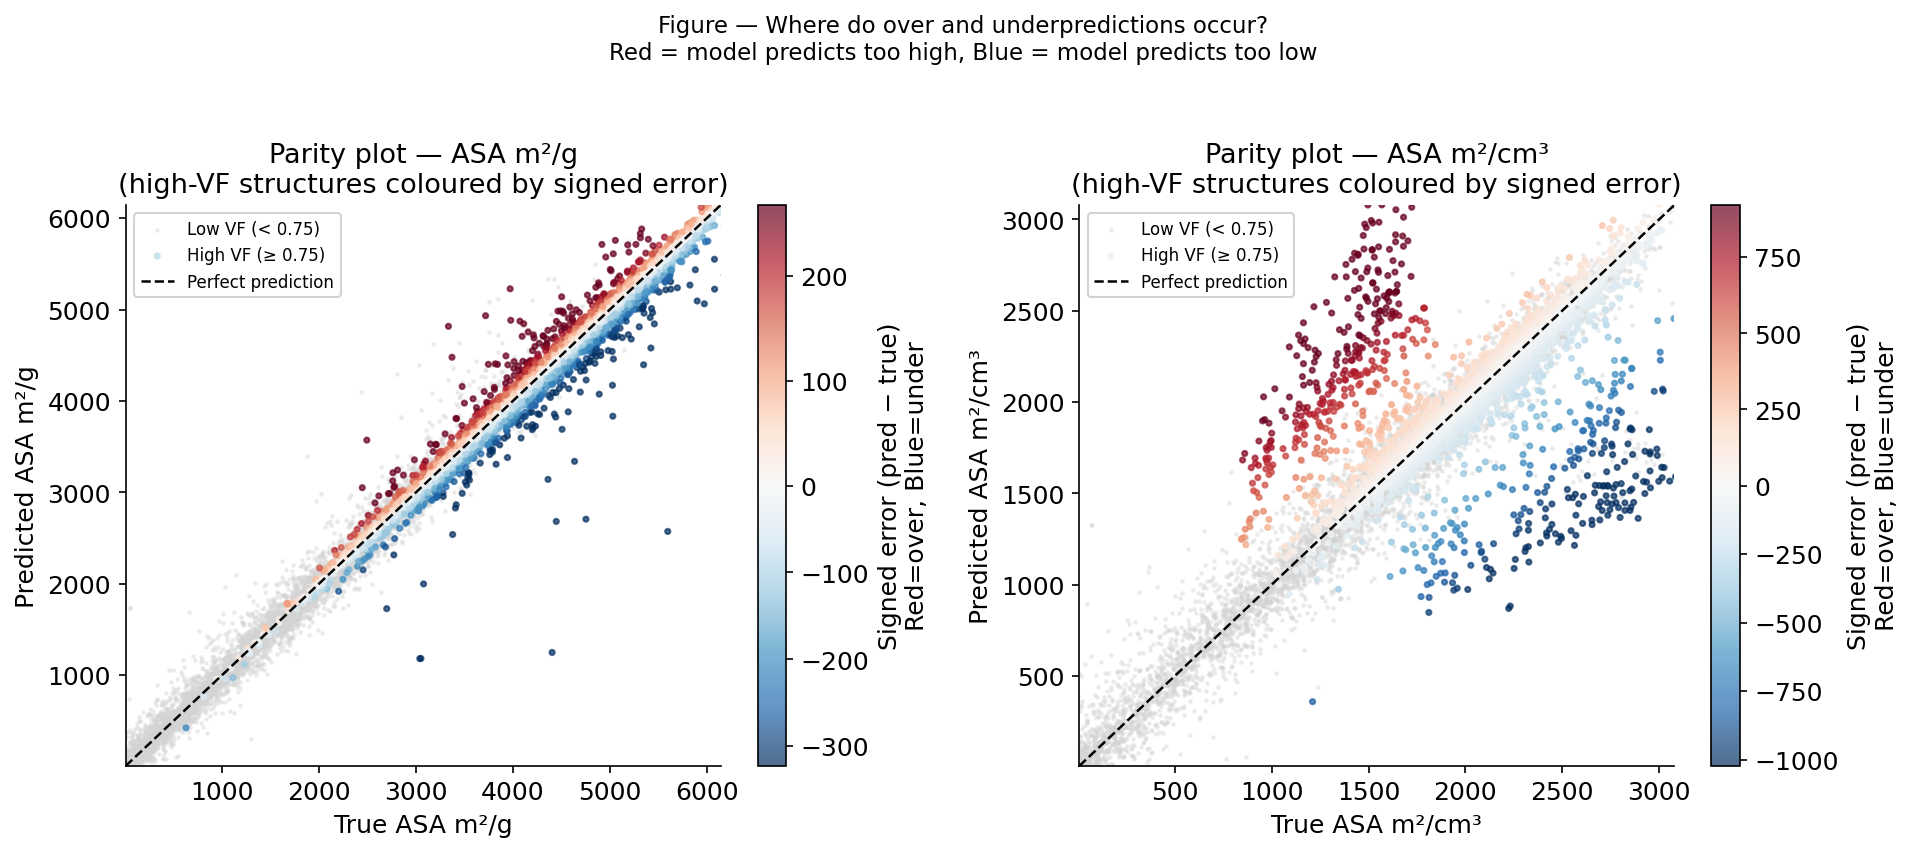

  Saved overunder_fig3_parity_signed.png
Generating Figure 4 — LCD vs signed error...


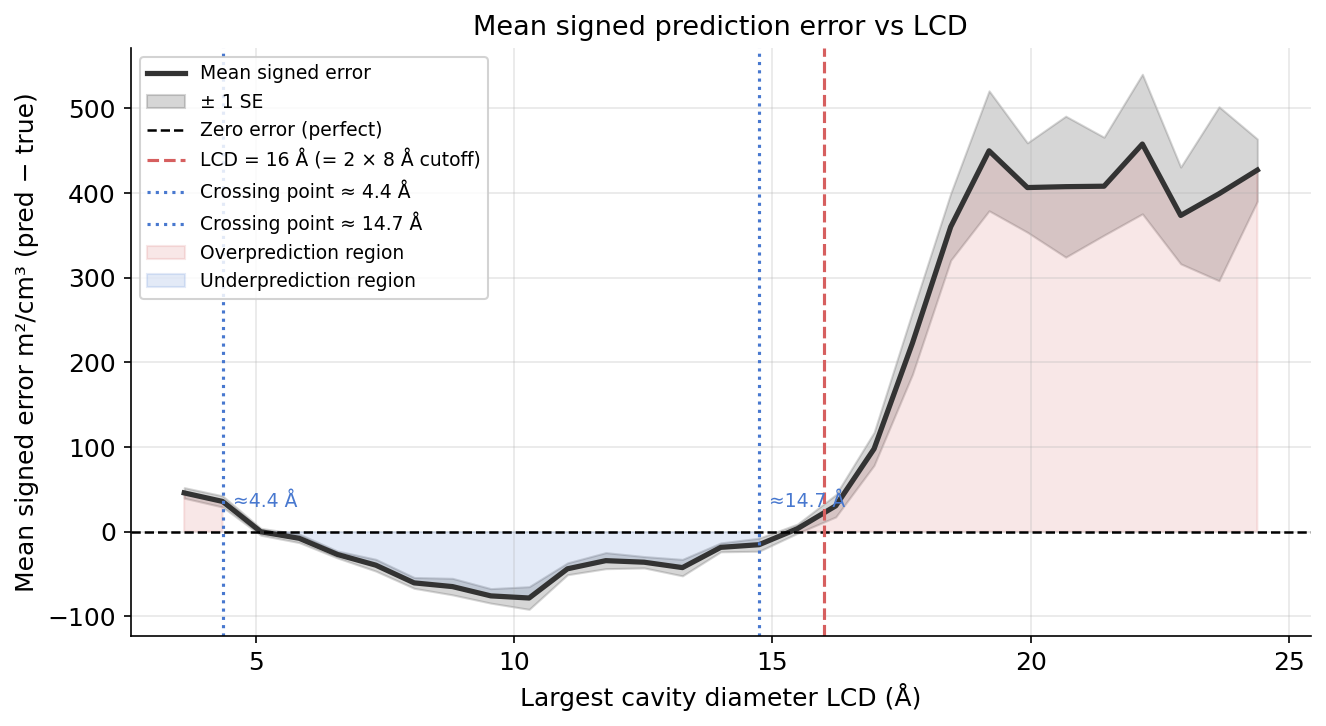

  Saved overunder_fig4_lcd_vs_signed_error.png

OVER vs UNDERPREDICTION SUMMARY

All test structures (n=13,132):
  Mean signed error m2/g   : +0.7
  Mean signed error m2/cm3 : -6.3

High void fraction (VF >= 0.75, n=4,918):
  Overpredicted  : 2,297 (46.7%)
  Underpredicted : 2,621 (53.3%)

  Feature means — overpredicted vs underpredicted:
  Feature                 Over mean   Under mean   Difference
  ------------------------------------------------------------
  LCD (Å)                    14.637       12.540       +2.097
  PLD (Å)                    13.198       10.910       +2.288
  Void fraction               0.838        0.820       +0.018
  Density                     0.467        0.522       -0.055

All figures saved to ./asa_analysis_output/


In [ ]:
# OVER vs UNDERPREDICTION ANALYSIS

import os, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

OUTPUT_DIR = "./asa_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})

ZIP_M2G   = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2g_alignn.zip")
ZIP_M2CM3 = os.path.expanduser("~/Downloads/alignn/alignn/hmof_surface_area_m2cm3_alignn.zip")
LCD_THRESHOLD   = 16.0
HIGH_VF_CUTOFF  = 0.75   # "high void fraction" threshold

# Load predictions

print("Reading prediction CSVs from zip files...")
with zipfile.ZipFile(ZIP_M2G) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    df_m2g = pd.read_csv(io.BytesIO(zp.read(csv_name)),
                         names=["id","true_m2g","pred_m2g"], skiprows=1)

with zipfile.ZipFile(ZIP_M2CM3) as zp:
    csv_name = next(n for n in zp.namelist() if "prediction_results_test_set" in n)
    df_m2cm3 = pd.read_csv(io.BytesIO(zp.read(csv_name)),
                            names=["id","true_m2cm3","pred_m2cm3"], skiprows=1)

for df in [df_m2g, df_m2cm3]:
    df["id"] = df["id"].astype(str).str.strip()

pred_df = df_m2g.merge(df_m2cm3, on="id")
print(f"  {len(pred_df)} structures with both predictions")

# Load hMOF features

print("Loading hMOF dataset...")
from jarvis.db.figshare import data as jdata
raw = jdata("hmof")

records = []
for row in raw:
    try:
        lat     = np.array(row["atoms"]["lattice_mat"])
        vol     = abs(np.linalg.det(lat))
        n_atoms = len(row["atoms"]["elements"])
        records.append({
            "id":                 str(row["id"]),
            "surface_area_m2g":   float(row.get("surface_area_m2g",   np.nan)),
            "surface_area_m2cm3": float(row.get("surface_area_m2cm3", np.nan)),
            "void_fraction":      float(row.get("void_fraction",       np.nan)),
            "lcd":                float(row.get("lcd",                 np.nan)),
            "pld":                float(row.get("pld",                 np.nan)),
            "unit_cell_volume":   vol,
            "n_atoms":            n_atoms,
            "vol_per_atom":       vol / n_atoms,
        })
    except Exception:
        continue

hmof_df = pd.DataFrame(records).dropna(
    subset=["surface_area_m2g","surface_area_m2cm3","lcd"])
valid = hmof_df["surface_area_m2g"] > 0
hmof_df.loc[valid, "density"] = (
    hmof_df.loc[valid, "surface_area_m2cm3"] / hmof_df.loc[valid, "surface_area_m2g"]
)
hmof_df = hmof_df.dropna(subset=["density"])

# Merge and compute signed error
# SIGNED error = pred - true
#   positive → model OVERPREDICTS (thinks m2/cm3 is higher than it is)
#   negative → model UNDERPREDICTS (thinks m2/cm3 is lower than it is)

merged = pred_df.merge(hmof_df, on="id", how="inner")
merged["err_m2g"]          = merged["pred_m2g"]   - merged["true_m2g"]   # signed
merged["err_m2cm3"]        = merged["pred_m2cm3"] - merged["true_m2cm3"] # signed
merged["abs_err_m2g"]      = merged["err_m2g"].abs()
merged["abs_err_m2cm3"]    = merged["err_m2cm3"].abs()

# Classify each structure
merged["over_m2cm3"]  = merged["err_m2cm3"] > 0
merged["high_vf"]     = merged["void_fraction"] >= HIGH_VF_CUTOFF
merged["large_pore"]  = merged["lcd"] > LCD_THRESHOLD

# Among high-void-fraction structures, split into over and underpredicted
high_vf = merged[merged["high_vf"]].copy()
over     = high_vf[high_vf["over_m2cm3"]]
under    = high_vf[~high_vf["over_m2cm3"]]

print(f"\nHigh void fraction (VF >= {HIGH_VF_CUTOFF}) structures: {len(high_vf):,}")
print(f"  Overpredicted  (pred > true): {len(over):,}  "
      f"({100*len(over)/len(high_vf):.1f}%)")
print(f"  Underpredicted (pred < true): {len(under):,}  "
      f"({100*len(under)/len(high_vf):.1f}%)")

# Signed error distribution for high-VF MOFs
# Shows the full distribution of signed errors, split by pore size.
# If the cutoff hypothesis is right, the large-pore group should be
# heavily right-skewed (mostly overpredictions).

print("\nGenerating Figure 1 — signed error distributions...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat_thresh, feat_col, feat_label, group_labels in [
    (axes[0], LCD_THRESHOLD,  "lcd",
     "LCD (Å)",
     [f"LCD ≤ {LCD_THRESHOLD:.0f} Å", f"LCD > {LCD_THRESHOLD:.0f} Å"]),
    (axes[1], 0.85, "void_fraction",
     "Void fraction",
     ["VF 0.75–0.85", "VF > 0.85"]),
]:
    if feat_col == "lcd":
        mask_a = high_vf["lcd"] <= feat_thresh
    else:
        mask_a = high_vf["void_fraction"] <= feat_thresh

    grp_a = high_vf.loc[mask_a,  "err_m2cm3"]
    grp_b = high_vf.loc[~mask_a, "err_m2cm3"]

    bins = np.linspace(high_vf["err_m2cm3"].quantile(0.01),
                       high_vf["err_m2cm3"].quantile(0.99), 60)

    ax.hist(grp_a, bins=bins, alpha=0.6, color="#4878CF",
            label=f"{group_labels[0]} (n={len(grp_a):,})", density=True)
    ax.hist(grp_b, bins=bins, alpha=0.6, color="#D65F5F",
            label=f"{group_labels[1]} (n={len(grp_b):,})", density=True)

    ax.axvline(0, color="black", linewidth=1.5, linestyle="--",
               label="Zero error (perfect)")
    ax.axvline(grp_a.mean(), color="#4878CF", linewidth=1.5, linestyle=":",
               label=f"Mean {group_labels[0]}: {grp_a.mean():.0f}")
    ax.axvline(grp_b.mean(), color="#D65F5F", linewidth=1.5, linestyle=":",
               label=f"Mean {group_labels[1]}: {grp_b.mean():.0f}")

    ax.set_xlabel(f"Signed error m²/cm³ (pred − true)")
    ax.set_ylabel("Density")
    ax.set_title(f"Over/underprediction split by {feat_label}\n"
                 f"(high void fraction MOFs only, VF ≥ {HIGH_VF_CUTOFF})")
    ax.legend(fontsize=8, framealpha=0.85)

fig.suptitle(
    "Figure — Signed m²/cm³ prediction error for high-void-fraction MOFs\n"
    "Positive = overprediction, Negative = underprediction",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overunder_fig1_signed_error_dist.png"))
plt.show()
print("  Saved overunder_fig1_signed_error_dist.png")
print("Generating Figure 2 — feature comparison over vs underpredicted...")

features = [
    ("lcd",              "LCD (Å)"),
    ("pld",              "PLD (Å)"),
    ("void_fraction",    "Void fraction"),
    ("density",          "Density (g/cm³)"),
    ("unit_cell_volume", "Unit cell volume (Å³)"),
    ("vol_per_atom",     "Volume per atom (Å³)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (feat_col, feat_label) in zip(axes, features):
    over_vals  = over[feat_col].dropna()
    under_vals = under[feat_col].dropna()

    use_log = feat_col in ["unit_cell_volume", "vol_per_atom"]

    if use_log:
        over_vals  = np.log10(over_vals.clip(lower=1e-3))
        under_vals = np.log10(under_vals.clip(lower=1e-3))
        xlabel = f"{feat_label} (log₁₀)"
    else:
        xlabel = feat_label

    combined = pd.concat([over_vals, under_vals])
    bins = np.linspace(combined.quantile(0.01), combined.quantile(0.99), 40)

    ax.hist(over_vals,  bins=bins, alpha=0.6, color="#D65F5F", density=True,
            label=f"Overpredicted (n={len(over):,})\nmean={over[feat_col].mean():.2f}")
    ax.hist(under_vals, bins=bins, alpha=0.6, color="#4878CF", density=True,
            label=f"Underpredicted (n={len(under):,})\nmean={under[feat_col].mean():.2f}")

    # KS test to quantify how different the distributions are
    ks_stat, ks_p = stats.ks_2samp(over_vals, under_vals)
    ax.text(0.97, 0.97, f"KS={ks_stat:.3f}\np={ks_p:.1e}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution of {feat_label}")
    ax.legend(fontsize=8, framealpha=0.85)

fig.suptitle(
    "Figure — Structural features of overpredicted vs underpredicted\n"
    "high-void-fraction MOFs (m²/cm³, VF ≥ 0.75)\n"
    "KS statistic measures how different the two distributions are (higher = more different)",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overunder_fig2_feature_comparison.png"))
plt.show()
print("  Saved overunder_fig2_feature_comparison.png")

# Parity plot coloured by signed error direction

print("Generating Figure 3 — parity plot coloured by error direction...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, true_col, pred_col, err_col, label in [
    (axes[0], "true_m2g",   "pred_m2g",   "err_m2g",   "ASA m²/g"),
    (axes[1], "true_m2cm3", "pred_m2cm3", "err_m2cm3", "ASA m²/cm³"),
]:
    # Low VF background (grey)
    low_vf = merged[~merged["high_vf"]]
    ax.scatter(low_vf[true_col], low_vf[pred_col],
               c="lightgray", s=2, alpha=0.3, rasterized=True,
               label=f"Low VF (< {HIGH_VF_CUTOFF})")

    # High VF: colour by signed error magnitude and direction
    # Use a diverging colormap centred at zero
    hv = merged[merged["high_vf"]].copy()
    err_cap = hv[err_col].quantile(0.98)
    err_floor = hv[err_col].quantile(0.02)
    norm = mcolors.TwoSlopeNorm(
        vmin=max(err_floor, -2000),
        vcenter=0,
        vmax=min(err_cap, 2000)
    )
    sc = ax.scatter(hv[true_col], hv[pred_col],
                    c=hv[err_col], cmap="RdBu_r",
                    norm=norm, s=6, alpha=0.7, rasterized=True,
                    label=f"High VF (≥ {HIGH_VF_CUTOFF})")
    plt.colorbar(sc, ax=ax, label=f"Signed error (pred − true)\nRed=over, Blue=under")

    lo = min(merged[true_col].quantile(0.005), merged[pred_col].quantile(0.005))
    hi = max(merged[true_col].quantile(0.995), merged[pred_col].quantile(0.995))
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="Perfect prediction")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"True {label}"); ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"Parity plot — {label}\n"
                 f"(high-VF structures coloured by signed error)")
    ax.legend(fontsize=8, framealpha=0.85, loc="upper left")

fig.suptitle(
    "Figure — Where do over and underpredictions occur?\n"
    "Red = model predicts too high, Blue = model predicts too low",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overunder_fig3_parity_signed.png"))
plt.show()
print("  Saved overunder_fig3_parity_signed.png")

# LCD vs signed error

print("Generating Figure 4 — LCD vs signed error...")

fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(merged["lcd"].quantile(0.005),
                   merged["lcd"].quantile(0.995), 30)
bin_idx = np.clip(np.digitize(merged["lcd"], bins) - 1, 0, len(bins) - 2)

mean_err, std_err, centres, n_per_bin = [], [], [], []
for b in range(len(bins) - 1):
    mask = bin_idx == b
    if mask.sum() < 10: continue
    vals = merged.loc[mask, "err_m2cm3"]
    mean_err.append(vals.mean())
    std_err.append(vals.std() / np.sqrt(len(vals)))  # standard error
    centres.append((bins[b] + bins[b+1]) / 2)
    n_per_bin.append(mask.sum())

mean_err = np.array(mean_err)
std_err  = np.array(std_err)
centres  = np.array(centres)

ax.plot(centres, mean_err, color="#333333", linewidth=2.5,
        label="Mean signed error")
ax.fill_between(centres, mean_err - std_err, mean_err + std_err,
                alpha=0.2, color="#333333", label="± 1 SE")

ax.axhline(0, color="black", linestyle="--", linewidth=1.2,
           label="Zero error (perfect)")
ax.axvline(LCD_THRESHOLD, color="#D65F5F", linestyle="--", linewidth=1.5,
           label=f"LCD = {LCD_THRESHOLD:.0f} Å (= 2 × 8 Å cutoff)")

# Find and annotate the crossing point (where model transitions over→under)
sign_changes = np.where(np.diff(np.sign(mean_err)))[0]
for idx in sign_changes:
    x_cross = centres[idx]
    ax.axvline(x_cross, color="#4878CF", linestyle=":",
               linewidth=1.5, label=f"Crossing point ≈ {x_cross:.1f} Å")
    ax.text(x_cross + 0.2, ax.get_ylim()[1] * 0.05 if len(ax.get_ylim()) > 0
            else 50,
            f"≈{x_cross:.1f} Å", color="#4878CF", fontsize=9)

ax.fill_between(centres, mean_err, 0,
                where=(mean_err > 0), alpha=0.15, color="#D65F5F",
                label="Overprediction region")
ax.fill_between(centres, mean_err, 0,
                where=(mean_err < 0), alpha=0.15, color="#4878CF",
                label="Underprediction region")

ax.set_xlabel("Largest cavity diameter LCD (Å)")
ax.set_ylabel("Mean signed error m²/cm³ (pred − true)")
ax.set_title("Mean signed prediction error vs LCD")
ax.legend(fontsize=9, framealpha=0.85)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overunder_fig4_lcd_vs_signed_error.png"))
plt.show()
print("  Saved overunder_fig4_lcd_vs_signed_error.png")

# STATISTICS

print("\n" + "="*65)
print("OVER vs UNDERPREDICTION SUMMARY")
print("="*65)

print(f"\nAll test structures (n={len(merged):,}):")
print(f"  Mean signed error m2/g   : {merged['err_m2g'].mean():+.1f}")
print(f"  Mean signed error m2/cm3 : {merged['err_m2cm3'].mean():+.1f}")

print(f"\nHigh void fraction (VF >= {HIGH_VF_CUTOFF}, n={len(high_vf):,}):")
print(f"  Overpredicted  : {len(over):,} ({100*len(over)/len(high_vf):.1f}%)")
print(f"  Underpredicted : {len(under):,} ({100*len(under)/len(high_vf):.1f}%)")
print(f"\n  Feature means — overpredicted vs underpredicted:")
print(f"  {'Feature':<20} {'Over mean':>12} {'Under mean':>12} {'Difference':>12}")
print("  " + "-"*60)
for feat_col, feat_label in [
    ("lcd",           "LCD (Å)"),
    ("pld",           "PLD (Å)"),
    ("void_fraction", "Void fraction"),
    ("density",       "Density"),
]:
    om = over[feat_col].mean()
    um = under[feat_col].mean()
    print(f"  {feat_label:<20} {om:>12.3f} {um:>12.3f} {om-um:>+12.3f}")

print(f"\nAll figures saved to {OUTPUT_DIR}/")